# z(0) Constraint Exploration: Key Findings

This notebook investigated whether constraining z(0) = 0 helps autoencoder training.

**Bottom line**: Two lessons emerged that redirect our investigation.


## Lesson 1: z(0) = 0 Constraint Isn't Worth Enforcing

The z(0) location (where the zero vector maps in latent space) is essentially an arbitrary coordinate choice:

**If enforced during training:**
- Requires computing `encoder(0)` every forward pass and subtracting it
- Extra computation for no benefit

**If done post-hoc:**
- Just define: `encoder_new(x) = encoder(x) - c` and `decoder_new(z) = decoder(z + c)` where `c = encoder(0)`
- This is a trivial coordinate shift that doesn't change the representation

**Conclusion**: Where z(0) ends up is like choosing the origin of a coordinate system — it doesn't affect what the representation can express. Don't constrain it.


## Lesson 2: Positive Homogeneity of Bias-Free Encoders

A more fundamental insight emerged: ReLU networks without biases are **positively homogeneous**:

$$f(t \cdot x) = t \cdot f(x) \quad \text{for } t > 0$$

### Simple intuition

1. **ReLU is linear in the positive regime**: When $x > 0$, $\text{ReLU}(x) = x$ (identity)
2. **Features stay positive**: Our input features are non-negative, and ReLU can't make them negative
3. **Therefore the transformation is linear**: We're always in the "linear regime" of every ReLU

With biases, the ReLU kinks can appear at non-zero locations, creating genuine nonlinearity. Without biases, the kinks are all at zero — and we never cross them.

### Formal statement

- For a single layer: $\text{ReLU}(W \cdot (t \cdot x)) = \text{ReLU}(t \cdot (W \cdot x)) = t \cdot \text{ReLU}(W \cdot x)$ for $t > 0$
- This property propagates through all layers
- Therefore: $\text{encoder}(t \cdot x) = t \cdot \text{encoder}(x)$

### Consequences

1. **Feature trajectories are perfectly linear**: $z(t \cdot e_i) = t \cdot z(e_i)$ — straight lines through origin
2. **Arc/chord ratio = 1.0 exactly**: Mathematically guaranteed, not coincidence
3. **Multiple encoder layers collapse**: Deep bias-free encoder = single linear projection

### Why are our features positive?

We're following the Toy Models of Superposition convention: features are sparse and non-negative. But is this essential or arbitrary?

**Arguments for positive features**:
- Many real features are naturally non-negative (word counts, pixel intensities, presence/absence)
- Sparsity is easier to define: "mostly zero" vs "mostly at some baseline"
- Interpretability: a feature being "on" vs "off" is cleaner than "positive" vs "negative"

**What if features could be negative?**
- The positive homogeneity argument breaks down — we'd cross ReLU kinks
- Bias-free networks could then be genuinely nonlinear
- But then what does "sparse" mean? Sparse around zero? Sparse deviations from a mean?

**Open question**: Is the positive-feature assumption hiding something important? Would results change qualitatively with signed features?

---

**Implication**: Removing encoder biases fundamentally changes network geometry, not just where z(0) is. The encoder becomes "write-linear" regardless of depth.

This raises a new question: **Is "write linear, read nonlinear" sufficient?** → See `write_linear_experiment.ipynb`


---

## Deprecated: Detailed Statistical Analysis

**Note**: The analysis below was conducted before understanding positive homogeneity. Given that bias-free encoders are fundamentally linear (due to positive homogeneity), the detailed performance comparisons between with-bias and without-bias encoders are less meaningful — we weren't just comparing "different z(0) locations" but fundamentally different encoder geometries.

The interesting question is now whether "write-linear + read-nonlinear" is sufficient for achieving good representations. See `write_linear_experiment.ipynb` for this follow-up investigation.

The cells below are preserved for reference but their conclusions should be interpreted with the above in mind.

---


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Import from core
from core import device, generate_sparse_data, Autoencoder, train_autoencoder

print(f"Using device: {device}")

Using device: cpu


## Modified Autoencoder with Optional Encoder Biases

In [2]:
class AutoencoderNoBias(nn.Module):
    """
    Autoencoder with configurable encoder biases.
    
    When encoder_bias=False, z(0) = 0 is guaranteed:
    - ReLU(W @ 0) = ReLU(0) = 0
    - So the zero input always maps to zero encoding
    
    Decoder keeps biases (they don't affect z(0)).
    """
    def __init__(self, n: int, m: int, l: int = 1, encoder_bias: bool = True):
        super().__init__()
        assert l >= 1
        self.n = n
        self.m = m
        self.l = l
        self.encoder_bias = encoder_bias
        
        # Build encoder: (l-1) layers of [Linear(n→n) + ReLU], then Linear(n→m)
        encoder_layers = []
        for i in range(l - 1):
            encoder_layers.append(nn.Linear(n, n, bias=encoder_bias))
            encoder_layers.append(nn.ReLU())
        encoder_layers.append(nn.Linear(n, m, bias=encoder_bias))  # final compression
        self.encoder = nn.Sequential(*encoder_layers)
        
        # Build decoder: always has biases
        decoder_layers = []
        decoder_layers.append(nn.Linear(m, n, bias=True))
        for i in range(l - 1):
            decoder_layers.append(nn.ReLU())
            decoder_layers.append(nn.Linear(n, n, bias=True))
        decoder_layers.append(nn.ReLU())  # Final ReLU for non-negative output
        self.decoder = nn.Sequential(*decoder_layers)
    
    def encode(self, x):
        return self.encoder(x)
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z

In [3]:
def train_model(model, n_steps=20000, batch_size=1024, S=0.9, lr=1e-3, weight_decay=1e-2, 
                verbose=True, use_cosine_schedule=True, early_stopping=True, 
                patience=2000, min_improvement=0.001):
    """
    Train a model and return losses.
    
    Args:
        model: the autoencoder model
        n_steps: maximum number of training steps
        batch_size: batch size for training
        S: sparsity level
        lr: initial learning rate
        weight_decay: weight decay for AdamW
        verbose: whether to show progress bar
        use_cosine_schedule: use cosine annealing LR schedule
        early_stopping: stop early if loss plateaus
        patience: steps to wait for improvement before stopping
        min_improvement: minimum relative improvement to reset patience
    
    Returns:
        list of training losses
    """
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # Cosine annealing schedule
    if use_cosine_schedule:
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_steps, eta_min=lr/100)
    
    losses = []
    best_loss = float('inf')
    steps_without_improvement = 0
    
    iterator = tqdm(range(n_steps)) if verbose else range(n_steps)
    for step in iterator:
        x = generate_sparse_data(batch_size, model.n, S)
        
        optimizer.zero_grad()
        x_recon, z = model(x)
        loss = nn.functional.mse_loss(x_recon, x)
        loss.backward()
        optimizer.step()
        
        if use_cosine_schedule:
            scheduler.step()
        
        current_loss = loss.item()
        losses.append(current_loss)
        
        # Early stopping check (use smoothed loss)
        if early_stopping and len(losses) >= 100:
            smoothed_loss = np.mean(losses[-100:])
            if smoothed_loss < best_loss * (1 - min_improvement):
                best_loss = smoothed_loss
                steps_without_improvement = 0
            else:
                steps_without_improvement += 1
            
            if steps_without_improvement >= patience:
                if verbose:
                    print(f"\nEarly stopping at step {step} (no improvement for {patience} steps)")
                break
        
        if verbose and step % 1000 == 0:
            lr_current = optimizer.param_groups[0]['lr']
            iterator.set_postfix({'loss': f'{current_loss:.6f}', 'lr': f'{lr_current:.2e}'})
    
    return losses

print("Training function updated with:")
print("  - Cosine annealing LR schedule")
print("  - Early stopping (patience=2000 steps, min_improvement=0.1%)")

Training function updated with:
  - Cosine annealing LR schedule
  - Early stopping (patience=2000 steps, min_improvement=0.1%)


## Evaluation Framework: Fixed Test Set

Instead of using the last 100 training losses (which have batch-to-batch noise), we evaluate all models on the same fixed test set. This isolates optimization variance from measurement variance.

In [4]:
# Test set configuration
TEST_SET_SIZE = 50000
TEST_SET_SEED = 99999  # Fixed seed for reproducibility

def generate_test_set(n, S, size=TEST_SET_SIZE, seed=TEST_SET_SEED):
    """Generate a fixed test set for evaluation."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    return generate_sparse_data(size, n, S)

def evaluate_model(model, test_x):
    """Evaluate a model on a fixed test set."""
    model.eval()
    with torch.no_grad():
        x_recon, z = model(test_x)
        loss = nn.functional.mse_loss(x_recon, test_x).item()
    return loss

print(f"Test set configuration: {TEST_SET_SIZE:,} samples, seed={TEST_SET_SEED}")

Test set configuration: 50,000 samples, seed=99999


## Experiment: Compare With vs Without Encoder Biases

In [5]:
# Experiment parameters
n = 5  # features
m = 2  # bottleneck
l = 2  # depth (nonlinear)
S = 0.9  # sparsity
n_steps = 10000  # increased from 10000 for better convergence
n_seeds = 20  # run multiple seeds for statistical power

# Generate fixed test set once
test_x = generate_test_set(n, S)
print(f"Test set shape: {test_x.shape}")
print(f"Training for {n_steps} steps per model...")

results_with_bias = []
results_no_bias = []

for seed in range(n_seeds):
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # With encoder biases (z(0) free)
    model_with = AutoencoderNoBias(n, m, l, encoder_bias=True).to(device)
    losses_with = train_model(model_with, n_steps=n_steps, S=S, verbose=False)
    test_loss_with = evaluate_model(model_with, test_x)
    results_with_bias.append({
        'model': model_with,
        'final_loss': test_loss_with,  # Now using test set evaluation
        'train_losses': losses_with
    })
    
    # Reset seed for fair comparison
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # Without encoder biases (z(0) = 0 forced)
    model_without = AutoencoderNoBias(n, m, l, encoder_bias=False).to(device)
    losses_without = train_model(model_without, n_steps=n_steps, S=S, verbose=False)
    test_loss_without = evaluate_model(model_without, test_x)
    results_no_bias.append({
        'model': model_without,
        'final_loss': test_loss_without,  # Now using test set evaluation
        'train_losses': losses_without
    })
    
    print(f"Seed {seed}: with_bias={test_loss_with:.6f}, no_bias={test_loss_without:.6f}")

print(f"\nAverage final loss (test set evaluation):")
print(f"  With encoder bias:    {np.mean([r['final_loss'] for r in results_with_bias]):.6f}")
print(f"  Without encoder bias: {np.mean([r['final_loss'] for r in results_no_bias]):.6f}")

Test set shape: torch.Size([50000, 5])
Training for 10000 steps per model...


Seed 0: with_bias=0.007650, no_bias=0.003146


Seed 1: with_bias=0.007857, no_bias=0.007884


Seed 2: with_bias=0.020345, no_bias=0.019942


Seed 3: with_bias=0.013784, no_bias=0.003032


...

Seed 15: with_bias=0.013883, no_bias=0.002824


Seed 16: with_bias=0.007872, no_bias=0.002754


Seed 17: with_bias=0.008048, no_bias=0.014003


Seed 18: with_bias=0.008354, no_bias=0.002692


Seed 19: with_bias=0.003951, no_bias=0.033566

Average final loss (test set evaluation):
  With encoder bias:    0.009922
  Without encoder bias: 0.010304


## Variance Diagnostic: Measurement vs Optimization

This diagnostic helps determine whether to invest in larger test sets or more seeds.
- **Measurement variance**: Same model evaluated on different test sets
- **Optimization variance**: Different models (seeds) evaluated on same test set

If measurement variance << optimization variance, the test set is large enough.

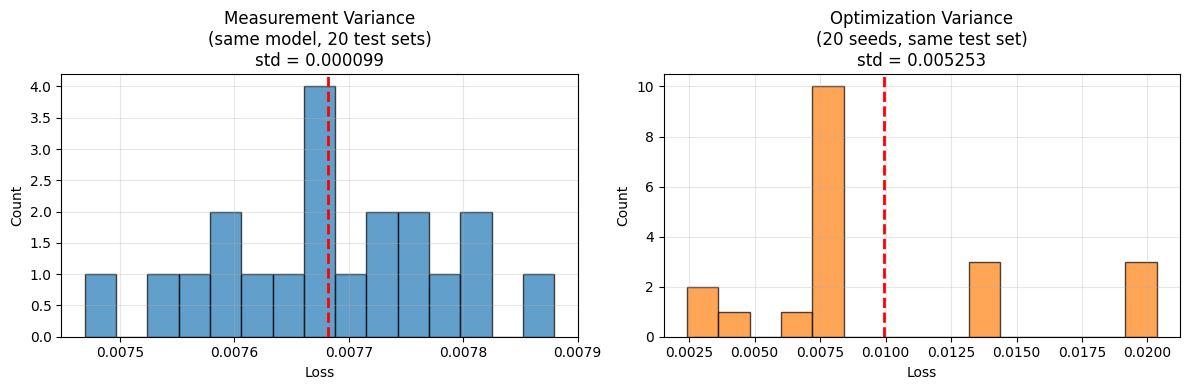

VARIANCE DIAGNOSTIC

Measurement variance (same model, different test sets):
  Mean: 0.007682
  Std:  0.000099

Optimization variance (different seeds, same test set):
  Mean: 0.009922
  Std:  0.005253

Ratio (optimization / measurement): 53.2x

→ Optimization variance dominates. Test set is large enough.
  Recommendation: More seeds will help more than larger test set.


In [6]:
# Variance diagnostic: measurement vs optimization
# Use one of the trained models to measure both sources of variance

reference_model = results_with_bias[0]['model']

# Measurement variance: same model, different test sets
n_test_sets = 20
measurement_losses = []
for i in range(n_test_sets):
    # Generate different test sets
    test_x_i = generate_test_set(n, S, size=TEST_SET_SIZE, seed=1000 + i)
    loss_i = evaluate_model(reference_model, test_x_i)
    measurement_losses.append(loss_i)

measurement_std = np.std(measurement_losses)
measurement_mean = np.mean(measurement_losses)

# Optimization variance: different models, same test set
optimization_losses = [r['final_loss'] for r in results_with_bias]
optimization_std = np.std(optimization_losses)
optimization_mean = np.mean(optimization_losses)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(measurement_losses, bins=15, alpha=0.7, edgecolor='black', label='Measurement')
ax.axvline(x=measurement_mean, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Loss')
ax.set_ylabel('Count')
ax.set_title(f'Measurement Variance\n(same model, {n_test_sets} test sets)\nstd = {measurement_std:.6f}')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(optimization_losses, bins=15, alpha=0.7, edgecolor='black', color='C1', label='Optimization')
ax.axvline(x=optimization_mean, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Loss')
ax.set_ylabel('Count')
ax.set_title(f'Optimization Variance\n({n_seeds} seeds, same test set)\nstd = {optimization_std:.6f}')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
print("=" * 60)
print("VARIANCE DIAGNOSTIC")
print("=" * 60)
print(f"\nMeasurement variance (same model, different test sets):")
print(f"  Mean: {measurement_mean:.6f}")
print(f"  Std:  {measurement_std:.6f}")
print(f"\nOptimization variance (different seeds, same test set):")
print(f"  Mean: {optimization_mean:.6f}")
print(f"  Std:  {optimization_std:.6f}")

ratio = optimization_std / measurement_std if measurement_std > 0 else float('inf')
print(f"\nRatio (optimization / measurement): {ratio:.1f}x")

if ratio > 10:
    print("\n→ Optimization variance dominates. Test set is large enough.")
    print("  Recommendation: More seeds will help more than larger test set.")
elif ratio > 3:
    print("\n→ Optimization variance is larger, but measurement noise is noticeable.")
    print("  Recommendation: Current test set size is reasonable.")
else:
    print("\n→ Measurement variance is significant relative to optimization variance.")
    print("  Recommendation: Consider increasing test set size.")

## Convergence Check

Verify that models have converged before trusting the final loss measurements. If models are still improving, the "final" loss is noisy and we might need more training steps.

CONVERGENCE CHECK

Condition            Converged    Last-Q Improv %    Late CV     
----------------------------------------------------------------------
with_bias            14/20         0.27               0.1171      
without_bias         11/20         0.26               0.1460      
----------------------------------------------------------------------


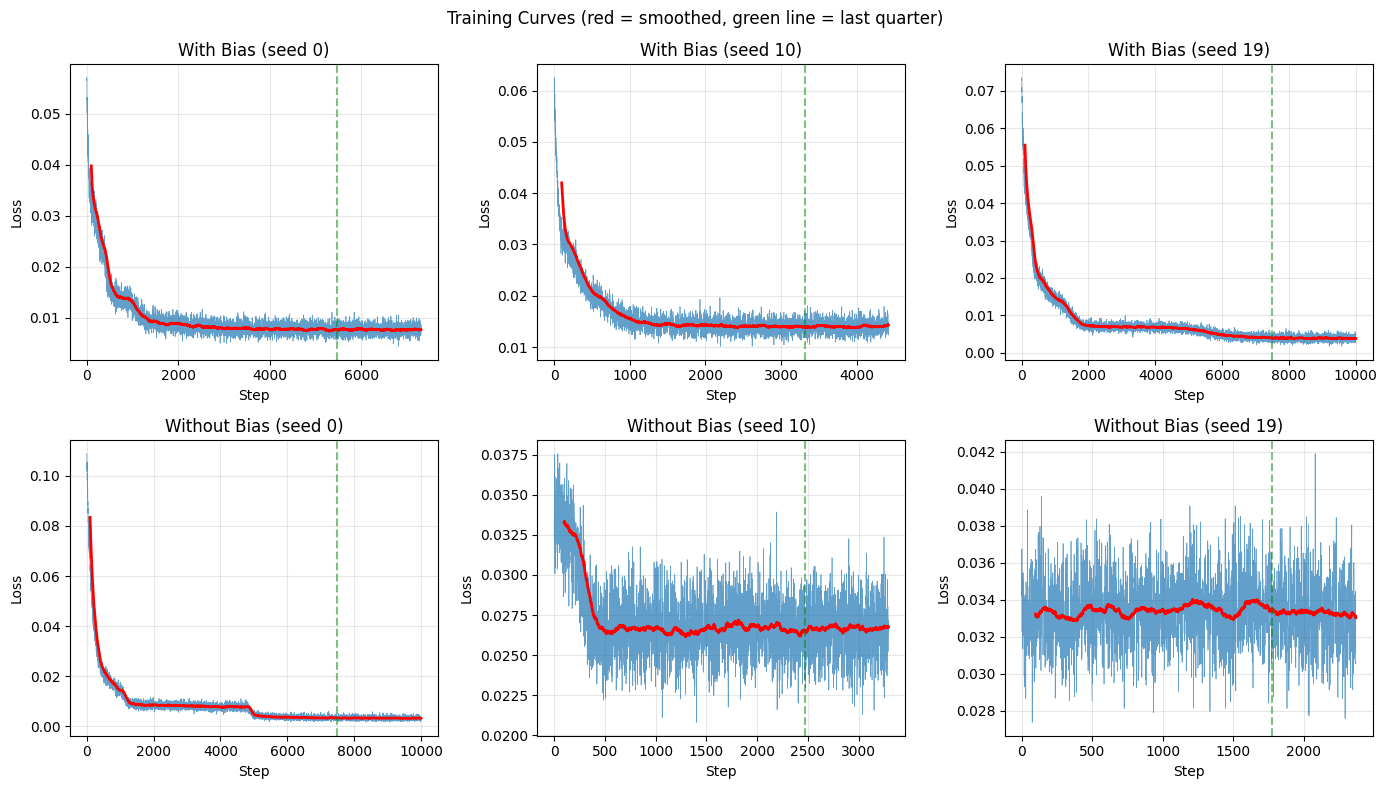


Overall Assessment:
⚠ 15 models still improving > 1% in last quarter
  Consider increasing n_steps for more reliable results
  Average last-quarter improvement: 0.26%


In [7]:
def check_convergence(train_losses, window_size=100, threshold_pct=1.0):
    """
    Check if training has converged by comparing early vs late loss windows.
    
    Args:
        train_losses: list of training losses
        window_size: size of windows to compare
        threshold_pct: max allowed % improvement in late window to be "converged"
    
    Returns:
        dict with convergence metrics
    """
    losses = np.array(train_losses)
    n = len(losses)
    
    # Compare first half vs second half
    mid = n // 2
    first_half_mean = np.mean(losses[:mid])
    second_half_mean = np.mean(losses[mid:])
    
    # Compare early window vs late window
    early_window = np.mean(losses[window_size:2*window_size])  # skip first window (warmup)
    late_window = np.mean(losses[-window_size:])
    
    # Improvement from early to late
    improvement_pct = (early_window - late_window) / early_window * 100
    
    # Variance in late window (should be low if converged)
    late_std = np.std(losses[-window_size:])
    late_cv = late_std / late_window  # coefficient of variation
    
    # Is the model still improving in the last portion?
    last_quarter = losses[3*n//4:]
    slope, _ = np.polyfit(range(len(last_quarter)), last_quarter, 1)
    still_decreasing = slope < 0
    
    # Relative improvement in last quarter
    last_quarter_start = np.mean(last_quarter[:window_size//2])
    last_quarter_end = np.mean(last_quarter[-window_size//2:])
    last_quarter_improvement_pct = (last_quarter_start - last_quarter_end) / last_quarter_start * 100
    
    converged = last_quarter_improvement_pct < threshold_pct
    
    return {
        'early_loss': early_window,
        'late_loss': late_window,
        'total_improvement_pct': improvement_pct,
        'last_quarter_improvement_pct': last_quarter_improvement_pct,
        'late_std': late_std,
        'late_cv': late_cv,
        'still_decreasing': still_decreasing,
        'converged': converged
    }


# Check convergence for all trained models
print("=" * 70)
print("CONVERGENCE CHECK")
print("=" * 70)

# Aggregate convergence stats
convergence_stats = {'with_bias': [], 'without_bias': []}

for i, (r_with, r_without) in enumerate(zip(results_with_bias, results_no_bias)):
    conv_with = check_convergence(r_with['train_losses'])
    conv_without = check_convergence(r_without['train_losses'])
    convergence_stats['with_bias'].append(conv_with)
    convergence_stats['without_bias'].append(conv_without)

# Summary statistics
print(f"\n{'Condition':<20} {'Converged':<12} {'Last-Q Improv %':<18} {'Late CV':<12}")
print("-" * 70)

for condition in ['with_bias', 'without_bias']:
    stats = convergence_stats[condition]
    n_converged = sum(1 for s in stats if s['converged'])
    avg_improvement = np.mean([s['last_quarter_improvement_pct'] for s in stats])
    avg_cv = np.mean([s['late_cv'] for s in stats])
    
    print(f"{condition:<20} {n_converged}/{len(stats):<10} {avg_improvement:<18.2f} {avg_cv:<12.4f}")

print("-" * 70)

# Visualize training curves for a few seeds
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for idx, seed_idx in enumerate([0, n_seeds//2, n_seeds-1]):
    # With bias
    ax = axes[0, idx]
    losses = results_with_bias[seed_idx]['train_losses']
    ax.plot(losses, alpha=0.7, linewidth=0.5)
    # Smoothed version
    window = 100
    smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
    ax.plot(range(window-1, len(losses)), smoothed, color='red', linewidth=2)
    ax.set_title(f'With Bias (seed {seed_idx})')
    ax.set_xlabel('Step')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)
    
    # Mark last quarter
    ax.axvline(x=3*len(losses)//4, color='green', linestyle='--', alpha=0.5)
    
    # Without bias
    ax = axes[1, idx]
    losses = results_no_bias[seed_idx]['train_losses']
    ax.plot(losses, alpha=0.7, linewidth=0.5)
    smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
    ax.plot(range(window-1, len(losses)), smoothed, color='red', linewidth=2)
    ax.set_title(f'Without Bias (seed {seed_idx})')
    ax.set_xlabel('Step')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)
    ax.axvline(x=3*len(losses)//4, color='green', linestyle='--', alpha=0.5)

plt.suptitle('Training Curves (red = smoothed, green line = last quarter)', fontsize=12)
plt.tight_layout()
plt.show()

# Overall assessment
all_converged = all(s['converged'] for s in convergence_stats['with_bias'] + convergence_stats['without_bias'])
avg_last_q_improvement = np.mean([s['last_quarter_improvement_pct'] 
                                   for s in convergence_stats['with_bias'] + convergence_stats['without_bias']])

print(f"\nOverall Assessment:")
if all_converged:
    print(f"✓ All models converged (< 1% improvement in last quarter)")
else:
    n_not_converged = sum(1 for s in convergence_stats['with_bias'] + convergence_stats['without_bias'] 
                          if not s['converged'])
    print(f"⚠ {n_not_converged} models still improving > 1% in last quarter")
    print(f"  Consider increasing n_steps for more reliable results")

print(f"  Average last-quarter improvement: {avg_last_q_improvement:.2f}%")

## Training Curve Analysis

Analyze training dynamics across all seeds.

In [8]:
# =============================================================================
# TRAINING CURVE CLASSIFICATION AND ANALYSIS
# =============================================================================

def classify_training_curve(losses, smoothing_window=100):
    """Classify a training curve into categories."""
    losses = np.array(losses)
    n = len(losses)
    
    if n >= smoothing_window:
        smoothed = np.convolve(losses, np.ones(smoothing_window)/smoothing_window, mode='valid')
    else:
        smoothed = losses
    
    final_loss = np.mean(losses[-100:]) if len(losses) >= 100 else losses[-1]
    initial_loss = np.mean(losses[:100]) if len(losses) >= 100 else losses[0]
    improvement_ratio = initial_loss / final_loss if final_loss > 0 else np.inf
    
    if len(smoothed) > 1:
        increases = np.sum(np.diff(smoothed) > 0)
        monotonicity = 1 - increases / (len(smoothed) - 1)
    else:
        monotonicity = 1.0
    
    last_10pct = losses[int(0.9*n):]
    final_stability = np.std(last_10pct) / np.mean(last_10pct) if np.mean(last_10pct) > 0 else np.inf
    
    if improvement_ratio < 1.5:
        category = 'failed'
    elif final_stability > 0.3:
        category = 'oscillating'
    elif monotonicity > 0.8 and final_stability < 0.1:
        category = 'smooth_converged'
    else:
        category = 'bumpy'
    
    return {'category': category, 'improvement_ratio': improvement_ratio}

def compare_training_dynamics(results_with, results_without):
    """Compare training dynamics between conditions."""
    cls_with = [classify_training_curve(r['train_losses']) for r in results_with]
    cls_without = [classify_training_curve(r['train_losses']) for r in results_without]
    
    categories = ['smooth_converged', 'bumpy', 'failed', 'oscillating']
    counts_with = {cat: sum(1 for c in cls_with if c['category'] == cat) for cat in categories}
    counts_without = {cat: sum(1 for c in cls_without if c['category'] == cat) for cat in categories}
    
    print("=" * 70)
    print("TRAINING DYNAMICS COMPARISON")
    print("=" * 70)
    print(f"\n{'Category':<20} {'With Bias':<12} {'Without Bias':<12}")
    print("-" * 45)
    for cat in categories:
        print(f"{cat:<20} {counts_with[cat]:<12} {counts_without[cat]:<12}")
    
    return {'counts_with': counts_with, 'counts_without': counts_without}

# Run training dynamics analysis
print("Analyzing training dynamics...\n")
training_dynamics = compare_training_dynamics(results_with_bias, results_no_bias)


Analyzing training dynamics...

TRAINING DYNAMICS COMPARISON

Category             With Bias    Without Bias
---------------------------------------------
smooth_converged     0            0           
bumpy                20           17          
failed               0            3           
oscillating          0            0           


## Verify z(0) Locations

In [9]:
# Check where x=0 maps to for each model
zero_input = torch.zeros(1, n).to(device)

print("z(0) locations:")
print("\nWith encoder bias:")
with torch.no_grad():
    for i, r in enumerate(results_with_bias):
        z0 = r['model'].encode(zero_input).cpu().numpy()[0]
        print(f"  Seed {i}: z(0) = [{z0[0]:.4f}, {z0[1]:.4f}], ||z(0)|| = {np.linalg.norm(z0):.4f}")

    print("\nWithout encoder bias:")
    for i, r in enumerate(results_no_bias):
        z0 = r['model'].encode(zero_input).cpu().numpy()[0]
        print(f"  Seed {i}: z(0) = [{z0[0]:.4f}, {z0[1]:.4f}], ||z(0)|| = {np.linalg.norm(z0):.4f}")

z(0) locations:

With encoder bias:
  Seed 0: z(0) = [0.0249, -0.5069], ||z(0)|| = 0.5075
  Seed 1: z(0) = [-0.0416, 0.1980], ||z(0)|| = 0.2023
  Seed 2: z(0) = [-0.1675, -0.5553], ||z(0)|| = 0.5800
  Seed 3: z(0) = [-0.2637, -0.4348], ||z(0)|| = 0.5085
  Seed 4: z(0) = [0.9119, 0.7465], ||z(0)|| = 1.1785
  Seed 5: z(0) = [0.0186, 0.3354], ||z(0)|| = 0.3359
  Seed 6: z(0) = [-0.1296, 1.1754], ||z(0)|| = 1.1825
  Seed 7: z(0) = [0.7585, 0.4287], ||z(0)|| = 0.8712
  Seed 8: z(0) = [-0.0716, 0.4399], ||z(0)|| = 0.4457
  Seed 9: z(0) = [1.2744, -0.4222], ||z(0)|| = 1.3426
  Seed 10: z(0) = [0.4913, 1.1523], ||z(0)|| = 1.2527
  Seed 11: z(0) = [-0.4715, -0.2359], ||z(0)|| = 0.5273
  Seed 12: z(0) = [0.1773, -0.5413], ||z(0)|| = 0.5696
  Seed 13: z(0) = [0.9864, -0.3785], ||z(0)|| = 1.0566
  Seed 14: z(0) = [0.7153, 0.0488], ||z(0)|| = 0.7169
  Seed 15: z(0) = [0.7194, -0.7088], ||z(0)|| = 1.0099
  Seed 16: z(0) = [0.0733, -0.7306], ||z(0)|| = 0.7343
  Seed 17: z(0) = [-0.2490, -0.9403], ||z

## Visualize Feature Trajectories: With vs Without Bias

In [10]:
def plot_feature_trajectories(model, ax, title, n_points=50):
    """Plot how each feature maps to z-space as its value varies 0→1."""
    model.eval()
    colors = plt.cm.tab10(np.linspace(0, 1, model.n))
    
    with torch.no_grad():
        for i in range(model.n):
            # Sweep feature i from 0 to 1
            x = torch.zeros(n_points, model.n).to(device)
            x[:, i] = torch.linspace(0, 1, n_points).to(device)
            z = model.encode(x).detach().cpu().numpy()
            
            ax.plot(z[:, 0], z[:, 1], '-', color=colors[i], linewidth=2, alpha=0.8)
            ax.scatter(z[-1, 0], z[-1, 1], s=100, color=colors[i], zorder=5, edgecolors='white')
            ax.annotate(f'f{i}', (z[-1, 0], z[-1, 1]), fontsize=9, ha='center', va='bottom')
    
        # Mark z(0)
        z0 = model.encode(torch.zeros(1, model.n).to(device)).detach().cpu().numpy()[0]
        ax.scatter(z0[0], z0[1], s=150, color='black', marker='x', zorder=10, linewidths=3)
        ax.annotate('z(0)', (z0[0], z0[1]), fontsize=10, ha='right', va='top')
    
    # Reference circle
    theta = np.linspace(0, 2*np.pi, 100)
    ax.plot(np.cos(theta), np.sin(theta), '--', color='gray', alpha=0.3)
    
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.2)
    ax.axvline(x=0, color='gray', linestyle='-', alpha=0.2)
    ax.set_xlabel('z₀')
    ax.set_ylabel('z₁')
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

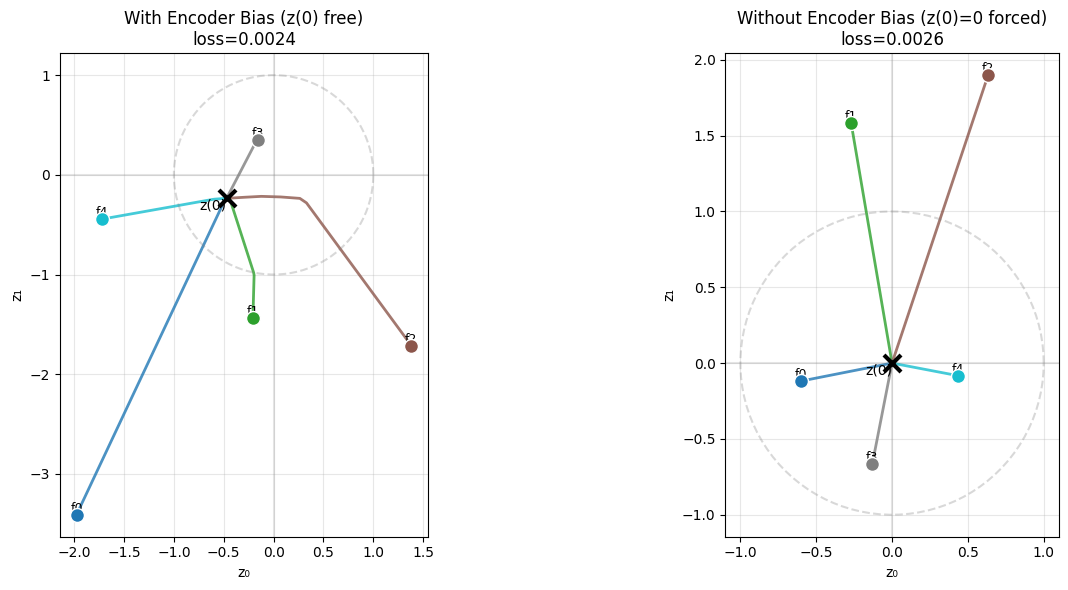

In [11]:
# Compare best models from each condition
best_with = min(results_with_bias, key=lambda r: r['final_loss'])
best_without = min(results_no_bias, key=lambda r: r['final_loss'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_feature_trajectories(
    best_with['model'], axes[0], 
    f"With Encoder Bias (z(0) free)\nloss={best_with['final_loss']:.4f}"
)

plot_feature_trajectories(
    best_without['model'], axes[1], 
    f"Without Encoder Bias (z(0)=0 forced)\nloss={best_without['final_loss']:.4f}"
)

plt.tight_layout()
plt.show()

## Arc/Chord Ratio Analysis

Quantify trajectory curvature (ratio=1: linear, ratio>1: curved).

In [12]:
# =============================================================================
# ARC/CHORD RATIO ANALYSIS  
# =============================================================================
from scipy import stats as sp_stats  # Avoid name collision

def compute_arc_chord_ratio(model, n_points=100):
    """Compute arc/chord ratio for each feature trajectory."""
    model.eval()
    n = model.n
    results = {'ratios': []}
    
    with torch.no_grad():
        for i in range(n):
            x = torch.zeros(n_points, n).to(device)
            x[:, i] = torch.linspace(0, 1, n_points).to(device)
            z = model.encode(x).detach().cpu().numpy()
            
            segments = np.diff(z, axis=0)
            arc_length = np.sum(np.linalg.norm(segments, axis=1))
            chord_length = np.linalg.norm(z[-1] - z[0])
            
            ratio = arc_length / chord_length if chord_length > 1e-10 else np.inf
            results['ratios'].append(ratio)
    
    finite_ratios = [r for r in results['ratios'] if np.isfinite(r)]
    results['mean_ratio'] = np.mean(finite_ratios) if finite_ratios else np.nan
    return results

def compare_arc_chord_ratios(results_with, results_without):
    """Compare arc/chord ratios between conditions."""
    all_ratios_with = []
    all_ratios_without = []
    
    for r in results_with:
        ac = compute_arc_chord_ratio(r['model'])
        all_ratios_with.extend([x for x in ac['ratios'] if np.isfinite(x)])
    
    for r in results_without:
        ac = compute_arc_chord_ratio(r['model'])
        all_ratios_without.extend([x for x in ac['ratios'] if np.isfinite(x)])
    
    print("=" * 70)
    print("ARC/CHORD RATIO ANALYSIS")
    print("=" * 70)
    print(f"\nMean arc/chord ratio:")
    print(f"  With bias:    {np.mean(all_ratios_with):.4f} (std={np.std(all_ratios_with):.4f})")
    print(f"  Without bias: {np.mean(all_ratios_without):.4f} (std={np.std(all_ratios_without):.4f})")
    
    u_stat, p_value = sp_stats.mannwhitneyu(all_ratios_with, all_ratios_without, alternative='two-sided')
    print(f"\nMann-Whitney U test: U={u_stat:.1f}, p={p_value:.4f}")
    
    return {'all_ratios_with': all_ratios_with, 'all_ratios_without': all_ratios_without, 'p_value': p_value}

# Run arc/chord analysis
print("Computing arc/chord ratios...\n")
arc_chord_results = compare_arc_chord_ratios(results_with_bias, results_no_bias)


Computing arc/chord ratios...

ARC/CHORD RATIO ANALYSIS

Mean arc/chord ratio:
  With bias:    1.0115 (std=0.0466)
  Without bias: 1.0000 (std=0.0000)

Mann-Whitney U test: U=8169.5, p=0.0000


## Check for Magnitude Superposition in Both

In [13]:
def analyze_feature_geometry(model, label):
    """Analyze angles and magnitudes of feature endpoints from z(0)."""
    model.eval()
    with torch.no_grad():
        z0 = model.encode(torch.zeros(1, model.n).to(device)).detach().cpu().numpy()[0]
        
        endpoints = []
        for i in range(model.n):
            x = torch.zeros(1, model.n).to(device)
            x[0, i] = 1.0
            z = model.encode(x).detach().cpu().numpy()[0]
            endpoints.append(z)
        
        endpoints = np.array(endpoints)
        
        # Vectors from z(0) to each feature endpoint
        vectors = endpoints - z0
        
        # Compute angles (from positive x-axis)
        angles = np.arctan2(vectors[:, 1], vectors[:, 0]) * 180 / np.pi
        
        # Compute magnitudes
        magnitudes = np.linalg.norm(vectors, axis=1)
        
        print(f"\n{label}:")
        print(f"  z(0) = [{z0[0]:.3f}, {z0[1]:.3f}]")
        print(f"  Feature angles from z(0): {[f'{a:.1f}°' for a in angles]}")
        print(f"  Feature magnitudes:       {[f'{m:.3f}' for m in magnitudes]}")
        
        # Check for similar angles (magnitude superposition signature)
        angle_diffs = []
        for i in range(len(angles)):
            for j in range(i+1, len(angles)):
                diff = abs(angles[i] - angles[j])
                if diff > 180:
                    diff = 360 - diff
                angle_diffs.append((i, j, diff))
        
        similar_pairs = [(i, j, d) for i, j, d in angle_diffs if d < 30]
        if similar_pairs:
            print(f"  Similar angle pairs (<30°): {[(f'f{i}-f{j}', f'{d:.1f}°') for i, j, d in similar_pairs]}")
        else:
            print(f"  No similar angle pairs (<30°) - using angular superposition")

analyze_feature_geometry(best_with['model'], "With Encoder Bias")
analyze_feature_geometry(best_without['model'], "Without Encoder Bias")


With Encoder Bias:
  z(0) = [-0.472, -0.236]
  Feature angles from z(0): ['-115.4°', '-77.5°', '-38.6°', '61.6°', '-170.5°']
  Feature magnitudes:       ['3.512', '1.224', '2.369', '0.667', '1.269']
  No similar angle pairs (<30°) - using angular superposition

Without Encoder Bias:
  z(0) = [0.000, 0.000]
  Feature angles from z(0): ['-168.8°', '99.7°', '71.6°', '-101.1°', '-10.8°']
  Feature magnitudes:       ['0.613', '1.602', '2.001', '0.676', '0.442']
  Similar angle pairs (<30°): [('f1-f2', '28.1°')]


## Statistical Comparison Across Seeds

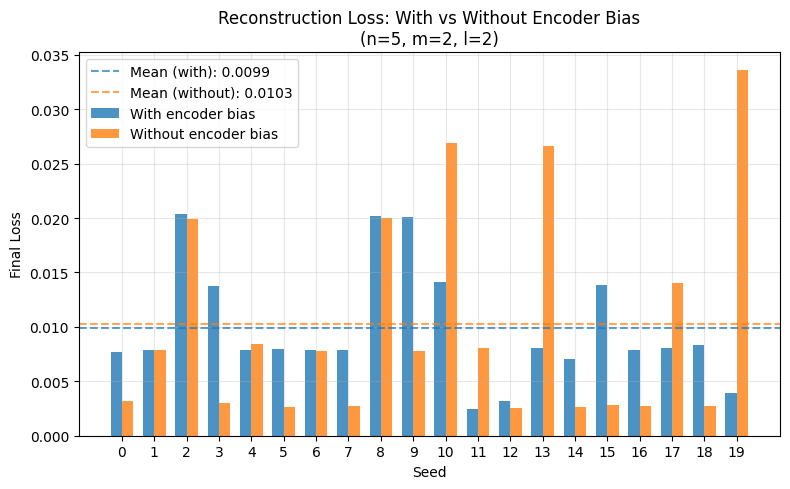


Difference: 0.000383 (+3.86%)
→ Less than 5% difference: z(0) freedom appears NOT useful


In [14]:
losses_with = [r['final_loss'] for r in results_with_bias]
losses_without = [r['final_loss'] for r in results_no_bias]

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(n_seeds)
width = 0.35

bars1 = ax.bar(x - width/2, losses_with, width, label='With encoder bias', alpha=0.8)
bars2 = ax.bar(x + width/2, losses_without, width, label='Without encoder bias', alpha=0.8)

ax.axhline(y=np.mean(losses_with), color='C0', linestyle='--', alpha=0.7, label=f'Mean (with): {np.mean(losses_with):.4f}')
ax.axhline(y=np.mean(losses_without), color='C1', linestyle='--', alpha=0.7, label=f'Mean (without): {np.mean(losses_without):.4f}')

ax.set_xlabel('Seed')
ax.set_ylabel('Final Loss')
ax.set_title(f'Reconstruction Loss: With vs Without Encoder Bias\n(n={n}, m={m}, l={l})')
ax.set_xticks(x)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Simple statistical test
diff = np.mean(losses_without) - np.mean(losses_with)
rel_diff = diff / np.mean(losses_with) * 100

print(f"\nDifference: {diff:.6f} ({rel_diff:+.2f}%)")
if abs(rel_diff) < 5:
    print("→ Less than 5% difference: z(0) freedom appears NOT useful")
else:
    print(f"→ Difference exceeds 5%: z(0) freedom may be {'helpful' if rel_diff > 0 else 'harmful'}")

## Statistical Significance Testing

Now we apply rigorous statistical tests to determine if the difference between conditions is significant.

In [15]:
from scipy import stats

def run_statistical_tests(losses_with, losses_without, alpha=0.05):
    """
    Run comprehensive statistical tests comparing two paired conditions.
    
    Args:
        losses_with: list of losses for 'with encoder bias' condition
        losses_without: list of losses for 'without encoder bias' condition
        alpha: significance level (default 0.05)
    
    Returns:
        dict with all test results
    """
    losses_with = np.array(losses_with)
    losses_without = np.array(losses_without)
    diffs = losses_without - losses_with  # positive = without is worse
    
    n = len(diffs)
    mean_diff = np.mean(diffs)
    std_diff = np.std(diffs, ddof=1)
    
    results = {
        'n_samples': n,
        'mean_diff': mean_diff,
        'std_diff': std_diff,
    }
    
    # --- Paired t-test ---
    t_stat, p_ttest = stats.ttest_rel(losses_without, losses_with)
    # 95% CI for mean difference
    se = std_diff / np.sqrt(n)
    t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
    ci_low = mean_diff - t_crit * se
    ci_high = mean_diff + t_crit * se
    
    results['ttest'] = {
        't_statistic': t_stat,
        'p_value': p_ttest,
        'ci_95': (ci_low, ci_high),
        'significant': p_ttest < alpha
    }
    
    # --- Wilcoxon signed-rank test (non-parametric) ---
    # Only valid if we have enough samples and non-zero differences
    if n >= 5 and not np.allclose(diffs, 0):
        try:
            w_stat, p_wilcoxon = stats.wilcoxon(losses_with, losses_without)
            results['wilcoxon'] = {
                'statistic': w_stat,
                'p_value': p_wilcoxon,
                'significant': p_wilcoxon < alpha
            }
        except ValueError as e:
            results['wilcoxon'] = {'error': str(e)}
    else:
        results['wilcoxon'] = {'error': 'Not enough samples or zero differences'}
    
    # --- Effect size (Cohen's d for paired samples) ---
    if std_diff > 0:
        cohens_d = mean_diff / std_diff
        # Interpretation
        if abs(cohens_d) < 0.2:
            effect_interp = 'negligible'
        elif abs(cohens_d) < 0.5:
            effect_interp = 'small'
        elif abs(cohens_d) < 0.8:
            effect_interp = 'medium'
        else:
            effect_interp = 'large'
        results['effect_size'] = {
            'cohens_d': cohens_d,
            'interpretation': effect_interp
        }
    else:
        results['effect_size'] = {'cohens_d': 0.0, 'interpretation': 'zero variance'}
    
    # --- Bootstrap confidence interval ---
    n_bootstrap = 10000
    np.random.seed(42)  # reproducibility
    boot_means = np.array([
        np.mean(np.random.choice(diffs, size=n, replace=True))
        for _ in range(n_bootstrap)
    ])
    boot_ci_low, boot_ci_high = np.percentile(boot_means, [2.5, 97.5])
    boot_excludes_zero = (boot_ci_low > 0) or (boot_ci_high < 0)
    
    results['bootstrap'] = {
        'ci_95': (boot_ci_low, boot_ci_high),
        'excludes_zero': boot_excludes_zero,
        'significant': boot_excludes_zero
    }
    
    # --- Check normality of differences (for t-test validity) ---
    if n >= 3:
        shapiro_stat, shapiro_p = stats.shapiro(diffs)
        results['normality_check'] = {
            'shapiro_statistic': shapiro_stat,
            'p_value': shapiro_p,
            'normal_at_alpha': shapiro_p > alpha
        }
    
    return results


def print_statistical_results(results):
    """Pretty-print statistical test results."""
    print("=" * 60)
    print("STATISTICAL SIGNIFICANCE TESTING")
    print("=" * 60)
    print(f"\nSample size: n = {results['n_samples']}")
    print(f"Mean difference (without - with): {results['mean_diff']:.6f}")
    print(f"Std of differences: {results['std_diff']:.6f}")
    
    print("\n--- Paired t-test ---")
    t = results['ttest']
    print(f"  t-statistic: {t['t_statistic']:.4f}")
    print(f"  p-value: {t['p_value']:.4f}")
    print(f"  95% CI: [{t['ci_95'][0]:.6f}, {t['ci_95'][1]:.6f}]")
    print(f"  Significant at α=0.05: {'YES' if t['significant'] else 'NO'}")
    
    print("\n--- Wilcoxon signed-rank test ---")
    w = results['wilcoxon']
    if 'error' in w:
        print(f"  {w['error']}")
    else:
        print(f"  W-statistic: {w['statistic']:.4f}")
        print(f"  p-value: {w['p_value']:.4f}")
        print(f"  Significant at α=0.05: {'YES' if w['significant'] else 'NO'}")
    
    print("\n--- Effect size (Cohen's d) ---")
    e = results['effect_size']
    print(f"  Cohen's d: {e['cohens_d']:.4f}")
    print(f"  Interpretation: {e['interpretation']}")
    
    print("\n--- Bootstrap 95% CI ---")
    b = results['bootstrap']
    print(f"  95% CI: [{b['ci_95'][0]:.6f}, {b['ci_95'][1]:.6f}]")
    print(f"  Excludes zero: {'YES' if b['excludes_zero'] else 'NO'}")
    
    if 'normality_check' in results:
        print("\n--- Normality check (Shapiro-Wilk) ---")
        n = results['normality_check']
        print(f"  p-value: {n['p_value']:.4f}")
        print(f"  Differences are normal (p > 0.05): {'YES' if n['normal_at_alpha'] else 'NO'}")
    
    # Overall conclusion
    print("\n" + "=" * 60)
    print("CONCLUSION")
    print("=" * 60)
    
    ttest_sig = results['ttest']['significant']
    effect_neg = results['effect_size']['interpretation'] == 'negligible'
    
    if not ttest_sig and effect_neg:
        print("✓ No significant difference AND negligible effect size.")
        print("  → Strong evidence that z(0) freedom does NOT matter.")
    elif not ttest_sig:
        print("✗ No significant difference, but effect size is not negligible.")
        print("  → Inconclusive. Consider increasing sample size.")
    elif ttest_sig and not effect_neg:
        direction = "WORSE" if results['mean_diff'] > 0 else "BETTER"
        print(f"✗ Significant difference with {results['effect_size']['interpretation']} effect.")
        print(f"  → Removing encoder bias makes performance {direction}.")
    else:
        print("? Significant difference but negligible effect size.")
        print("  → Statistically significant but not practically meaningful.")


# Run statistical tests on our experiment
losses_with = [r['final_loss'] for r in results_with_bias]
losses_without = [r['final_loss'] for r in results_no_bias]

stat_results = run_statistical_tests(losses_with, losses_without)
print_statistical_results(stat_results)

STATISTICAL SIGNIFICANCE TESTING

Sample size: n = 20
Mean difference (without - with): 0.000383
Std of differences: 0.010245

--- Paired t-test ---
  t-statistic: 0.1670
  p-value: 0.8691
  95% CI: [-0.004412, 0.005177]
  Significant at α=0.05: NO

--- Wilcoxon signed-rank test ---
  W-statistic: 89.0000
  p-value: 0.5706
  Significant at α=0.05: NO

--- Effect size (Cohen's d) ---
  Cohen's d: 0.0373
  Interpretation: negligible

--- Bootstrap 95% CI ---
  95% CI: [-0.003668, 0.005044]
  Excludes zero: NO

--- Normality check (Shapiro-Wilk) ---
  p-value: 0.0084
  Differences are normal (p > 0.05): NO

CONCLUSION
✓ No significant difference AND negligible effect size.
  → Strong evidence that z(0) freedom does NOT matter.


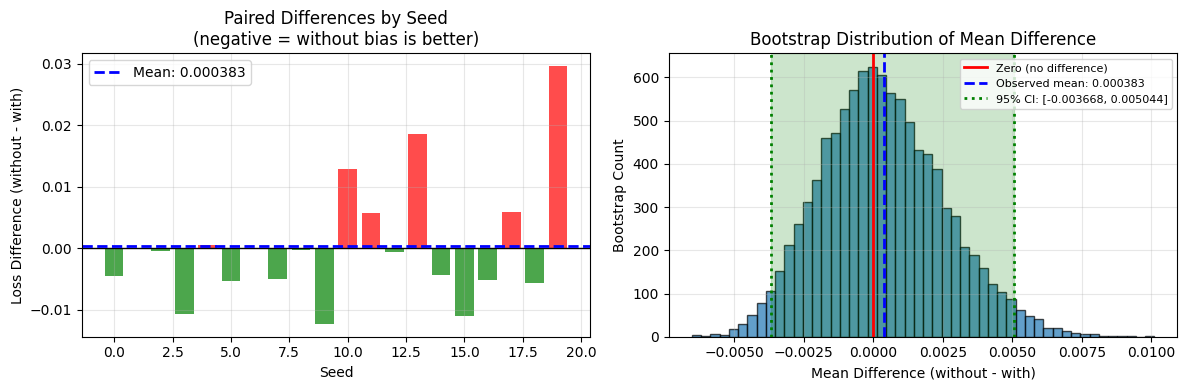

Zero falls within the 95% CI → No significant difference


In [16]:
# Visualize the paired differences and bootstrap distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Paired differences
diffs = np.array(losses_without) - np.array(losses_with)
ax = axes[0]
ax.bar(range(len(diffs)), diffs, color=['green' if d < 0 else 'red' for d in diffs], alpha=0.7)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.axhline(y=np.mean(diffs), color='blue', linestyle='--', linewidth=2, label=f'Mean: {np.mean(diffs):.6f}')
ax.set_xlabel('Seed')
ax.set_ylabel('Loss Difference (without - with)')
ax.set_title('Paired Differences by Seed\n(negative = without bias is better)')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: Bootstrap distribution
ax = axes[1]
n_bootstrap = 10000
np.random.seed(42)
boot_means = [np.mean(np.random.choice(diffs, size=len(diffs), replace=True)) for _ in range(n_bootstrap)]
ax.hist(boot_means, bins=50, alpha=0.7, edgecolor='black')
ax.axvline(x=0, color='red', linestyle='-', linewidth=2, label='Zero (no difference)')
ax.axvline(x=np.mean(diffs), color='blue', linestyle='--', linewidth=2, label=f'Observed mean: {np.mean(diffs):.6f}')

# Mark 95% CI
ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
ax.axvline(x=ci_low, color='green', linestyle=':', linewidth=2)
ax.axvline(x=ci_high, color='green', linestyle=':', linewidth=2, label=f'95% CI: [{ci_low:.6f}, {ci_high:.6f}]')
ax.axvspan(ci_low, ci_high, alpha=0.2, color='green')

ax.set_xlabel('Mean Difference (without - with)')
ax.set_ylabel('Bootstrap Count')
ax.set_title('Bootstrap Distribution of Mean Difference')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print whether zero falls within CI
if ci_low <= 0 <= ci_high:
    print("Zero falls within the 95% CI → No significant difference")
else:
    print("Zero falls outside the 95% CI → Significant difference")

## Unified Quantile Analysis Framework

Analyze results at multiple quantiles with bootstrap CIs.

In [17]:
# =============================================================================
# UNIFIED QUANTILE ANALYSIS FRAMEWORK
# =============================================================================

def quantile_analysis(losses_with, losses_without, n_bootstrap=10000, seed=42):
    """
    Compare conditions at multiple quantiles - from frontier to full distribution.
    """
    losses_with = np.array(losses_with)
    losses_without = np.array(losses_without)
    n = len(losses_with)
    np.random.seed(seed)

    quantiles = {
        'top_1': lambda x: np.min(x),
        'top_3': lambda x: np.mean(np.sort(x)[:min(3, len(x))]),
        'top_25pct': lambda x: np.mean(np.sort(x)[:max(1, len(x)//4)]),
        'median': lambda x: np.median(x),
        'all': lambda x: np.mean(x),
    }

    results = {}
    for name, fn in quantiles.items():
        val_with = fn(losses_with)
        val_without = fn(losses_without)
        diff = val_without - val_with
        pct_diff = diff / val_with * 100 if val_with > 0 else np.nan

        diffs = []
        for _ in range(n_bootstrap):
            sample_w = np.random.choice(losses_with, n, replace=True)
            sample_wo = np.random.choice(losses_without, n, replace=True)
            diffs.append(fn(sample_wo) - fn(sample_w))

        ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
        significant = not (ci_low <= 0 <= ci_high)

        results[name] = {
            'with': val_with, 'without': val_without,
            'diff': diff, 'pct_diff': pct_diff,
            'ci_95': (ci_low, ci_high), 'significant': significant,
        }
    return results

def print_quantile_analysis(results):
    print("=" * 85)
    print("QUANTILE PROGRESSION ANALYSIS")
    print("=" * 85)
    print("\nPositive diff = removing bias makes it WORSE; negative = BETTER\n")
    print(f"{'Quantile':<14} {'With':<12} {'Without':<12} {'Diff':<12} {'% Diff':<10} {'95% CI':<24} {'Sig?':<6}")
    print("-" * 85)
    for name, r in results.items():
        ci_str = f"[{r['ci_95'][0]:+.6f}, {r['ci_95'][1]:+.6f}]"
        sig_str = "YES*" if r['significant'] else "no"
        print(f"{name:<14} {r['with']:<12.6f} {r['without']:<12.6f} {r['diff']:<+12.6f} {r['pct_diff']:<+10.2f}% {ci_str:<24} {sig_str:<6}")
    print("-" * 85)
    n_sig = sum(1 for r in results.values() if r['significant'])
    print(f"\nSignificant at {n_sig}/{len(results)} quantile levels")

# Run quantile analysis
print("Running quantile analysis with bootstrap CIs...\n")
qa_results = quantile_analysis(
    [r['final_loss'] for r in results_with_bias],
    [r['final_loss'] for r in results_no_bias],
    n_bootstrap=10000
)
print_quantile_analysis(qa_results)


Running quantile analysis with bootstrap CIs...



QUANTILE PROGRESSION ANALYSIS

Positive diff = removing bias makes it WORSE; negative = BETTER

Quantile       With         Without      Diff         % Diff     95% CI                   Sig?  
-------------------------------------------------------------------------------------
top_1          0.002419     0.002572     +0.000153    +6.31     % [-0.004480, +0.000254]   no    
top_3          0.003193     0.002632     -0.000562    -17.58    % [-0.004819, +0.000245]   no    
top_25pct      0.004856     0.002668     -0.002188    -45.05    % [-0.004885, -0.000071]   YES*  
median         0.007912     0.007791     -0.000121    -1.53     % [-0.005603, +0.003331]   no    
all            0.009922     0.010304     +0.000383    +3.86     % [-0.004244, +0.005356]   no    
-------------------------------------------------------------------------------------

Significant at 1/5 quantile levels


## Empirical Minimum Scaling

How E[min | k] scales as you pool more seeds.


Computing minimum scaling curves...



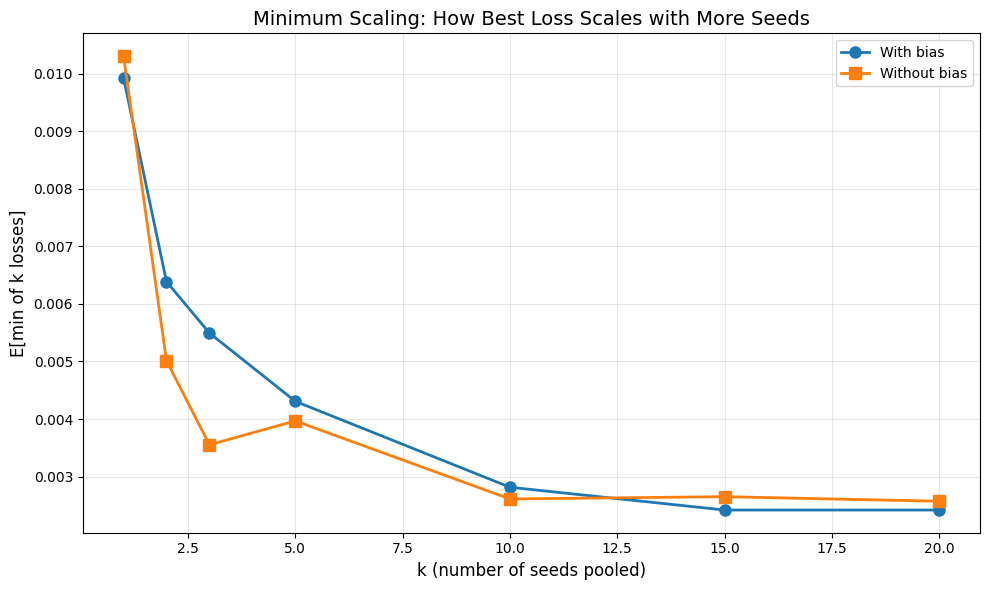

MINIMUM SCALING ANALYSIS

k        E[min|k] with    E[min|k] without Diff        
-------------------------------------------------------
1        0.009922         0.010304         +0.000383   
2        0.006386         0.005013         -0.001374   
3        0.005493         0.003553         -0.001941   
5        0.004308         0.003967         -0.000340   
10       0.002815         0.002611         -0.000203   
15       0.002419         0.002651         +0.000232   
20       0.002419         0.002572         +0.000153   


In [18]:
# =============================================================================
# EMPIRICAL MINIMUM SCALING
# =============================================================================

def empirical_min_scaling(losses, k_values=None):
    """Compute empirical min at multiple scales."""
    losses = np.array(losses)
    n = len(losses)
    if k_values is None:
        k_values = [k for k in [1, 2, 3, 5, 10, 15, 20] if k <= n]
    
    results = {}
    np.random.seed(42)
    shuffled = np.random.permutation(losses)
    
    for k in k_values:
        n_groups = n // k
        if n_groups < 1:
            continue
        mins = [np.min(shuffled[i*k:(i+1)*k]) for i in range(n_groups)]
        results[k] = {
            'mean_min': np.mean(mins),
            'se_min': np.std(mins) / np.sqrt(len(mins)) if len(mins) > 1 else np.nan,
        }
    return results

def compare_min_scaling_curves(losses_with, losses_without):
    """Compare how E[min | k] scales between conditions."""
    scaling_with = empirical_min_scaling(losses_with)
    scaling_without = empirical_min_scaling(losses_without)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    k_vals = sorted(set(scaling_with.keys()) & set(scaling_without.keys()))
    mean_with = [scaling_with[k]['mean_min'] for k in k_vals]
    mean_without = [scaling_without[k]['mean_min'] for k in k_vals]
    
    ax.plot(k_vals, mean_with, 'o-', color='C0', linewidth=2, markersize=8, label='With bias')
    ax.plot(k_vals, mean_without, 's-', color='C1', linewidth=2, markersize=8, label='Without bias')
    ax.set_xlabel('k (number of seeds pooled)', fontsize=12)
    ax.set_ylabel('E[min of k losses]', fontsize=12)
    ax.set_title('Minimum Scaling: How Best Loss Scales with More Seeds', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return {'scaling_with': scaling_with, 'scaling_without': scaling_without}

def print_min_scaling(scaling_with, scaling_without):
    print("=" * 70)
    print("MINIMUM SCALING ANALYSIS")
    print("=" * 70)
    print(f"\n{'k':<8} {'E[min|k] with':<16} {'E[min|k] without':<16} {'Diff':<12}")
    print("-" * 55)
    for k in sorted(scaling_with.keys()):
        if k in scaling_without:
            diff = scaling_without[k]['mean_min'] - scaling_with[k]['mean_min']
            print(f"{k:<8} {scaling_with[k]['mean_min']:<16.6f} {scaling_without[k]['mean_min']:<16.6f} {diff:<+12.6f}")

# Run min scaling analysis
print("\nComputing minimum scaling curves...\n")
losses_with_arr = np.array([r['final_loss'] for r in results_with_bias])
losses_without_arr = np.array([r['final_loss'] for r in results_no_bias])
scaling_results = compare_min_scaling_curves(losses_with_arr, losses_without_arr)
print_min_scaling(scaling_results['scaling_with'], scaling_results['scaling_without'])


## Sweep Across Depths

In [19]:
# Test across different depths with full statistical testing
l_values = [2, 4, 8]
n_seeds_sweep = 10

sweep_results = {}

# Use the same test set for all depths (already generated above)
# test_x was generated with n=5, S=0.9

for l_val in l_values:
    losses_with = []
    losses_without = []
    models_with = []
    models_without = []
    
    print(f"\n{'='*50}")
    print(f"Running l={l_val} ({n_seeds_sweep} seeds)...")
    print('='*50)
    
    for seed in range(n_seeds_sweep):
        torch.manual_seed(seed)
        np.random.seed(seed)
        
        model_with = AutoencoderNoBias(n, m, l_val, encoder_bias=True).to(device)
        train_model(model_with, n_steps=n_steps, S=S, verbose=False)
        test_loss_with = evaluate_model(model_with, test_x)
        losses_with.append(test_loss_with)
        models_with.append(model_with)
        
        torch.manual_seed(seed)
        np.random.seed(seed)
        
        model_without = AutoencoderNoBias(n, m, l_val, encoder_bias=False).to(device)
        train_model(model_without, n_steps=n_steps, S=S, verbose=False)
        test_loss_without = evaluate_model(model_without, test_x)
        losses_without.append(test_loss_without)
        models_without.append(model_without)
        
        if (seed + 1) % 5 == 0:
            print(f"  Completed {seed + 1}/{n_seeds_sweep} seeds")
    
    # Run statistical tests for this depth
    stat_results = run_statistical_tests(losses_with, losses_without)
    
    sweep_results[l_val] = {
        'losses_with': losses_with,
        'losses_without': losses_without,
        'models_with': models_with,
        'models_without': models_without,
        'with_bias_mean': np.mean(losses_with),
        'without_bias_mean': np.mean(losses_without),
        'diff_pct': (np.mean(losses_without) - np.mean(losses_with)) / np.mean(losses_with) * 100,
        'stats': stat_results
    }
    
    print(f"\nl={l_val} Results (test set evaluation):")
    print(f"  With bias:    {sweep_results[l_val]['with_bias_mean']:.6f}")
    print(f"  Without bias: {sweep_results[l_val]['without_bias_mean']:.6f}")
    print(f"  Diff: {sweep_results[l_val]['diff_pct']:+.2f}%")
    print(f"  t-test p-value: {stat_results['ttest']['p_value']:.4f}")
    print(f"  Cohen's d: {stat_results['effect_size']['cohens_d']:.4f} ({stat_results['effect_size']['interpretation']})")


Running l=2 (10 seeds)...


  Completed 5/10 seeds


  Completed 10/10 seeds

l=2 Results (test set evaluation):
  With bias:    0.012148
  Without bias: 0.008336
  Diff: -31.38%
  t-test p-value: 0.0297
  Cohen's d: -0.8157 (large)

Running l=4 (10 seeds)...


  Completed 5/10 seeds


  Completed 10/10 seeds

l=4 Results (test set evaluation):
  With bias:    0.021437
  Without bias: 0.019676
  Diff: -8.22%
  t-test p-value: 0.6877
  Cohen's d: -0.1313 (negligible)

Running l=8 (10 seeds)...


  Completed 5/10 seeds


  Completed 10/10 seeds

l=8 Results (test set evaluation):
  With bias:    0.022011
  Without bias: 0.024008
  Diff: +9.07%
  t-test p-value: 0.6160
  Cohen's d: 0.1642 (negligible)


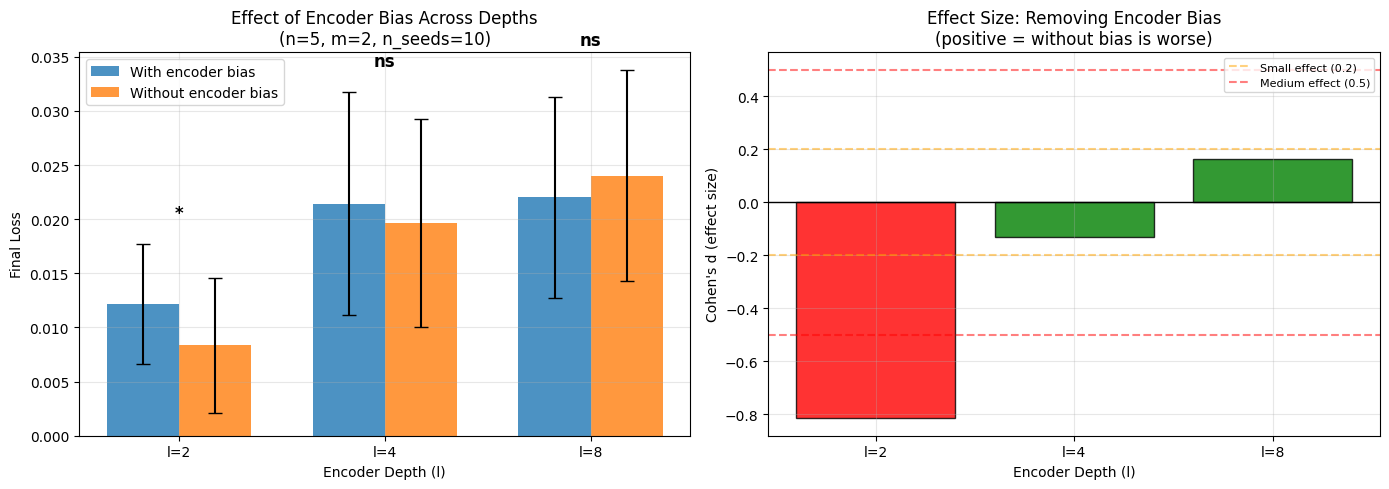


SUMMARY TABLE: Statistical Tests Across Depths
Depth    p-value      Cohen d      Effect       Significant?
----------------------------------------------------------------------
l=2     0.0297       -0.8157      large        YES         
l=4     0.6877       -0.1313      negligible   NO          
l=8     0.6160       0.1642       negligible   NO          


In [20]:
# Visualize sweep results with statistical annotations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

l_vals = list(sweep_results.keys())
with_vals = [sweep_results[l]['with_bias_mean'] for l in l_vals]
without_vals = [sweep_results[l]['without_bias_mean'] for l in l_vals]
with_stds = [np.std(sweep_results[l]['losses_with']) for l in l_vals]
without_stds = [np.std(sweep_results[l]['losses_without']) for l in l_vals]

# Left: Bar chart with error bars
ax = axes[0]
x = np.arange(len(l_vals))
width = 0.35

bars1 = ax.bar(x - width/2, with_vals, width, yerr=with_stds, capsize=5,
               label='With encoder bias', alpha=0.8)
bars2 = ax.bar(x + width/2, without_vals, width, yerr=without_stds, capsize=5,
               label='Without encoder bias', alpha=0.8)

# Add significance stars
for i, l_val in enumerate(l_vals):
    p = sweep_results[l_val]['stats']['ttest']['p_value']
    max_y = max(with_vals[i] + with_stds[i], without_vals[i] + without_stds[i])
    if p < 0.001:
        sig_label = '***'
    elif p < 0.01:
        sig_label = '**'
    elif p < 0.05:
        sig_label = '*'
    else:
        sig_label = 'ns'
    ax.text(x[i], max_y + 0.002, sig_label, ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Encoder Depth (l)')
ax.set_ylabel('Final Loss')
ax.set_title(f'Effect of Encoder Bias Across Depths\n(n={n}, m={m}, n_seeds={n_seeds_sweep})')
ax.set_xticks(x)
ax.set_xticklabels([f'l={l}' for l in l_vals])
ax.legend()
ax.grid(True, alpha=0.3)

# Right: Effect size summary
ax = axes[1]
cohens_ds = [sweep_results[l]['stats']['effect_size']['cohens_d'] for l in l_vals]
colors = ['green' if abs(d) < 0.2 else 'orange' if abs(d) < 0.5 else 'red' for d in cohens_ds]
bars = ax.bar(x, cohens_ds, color=colors, alpha=0.8, edgecolor='black')

# Add reference lines for effect size thresholds
ax.axhline(y=0.2, color='orange', linestyle='--', alpha=0.5, label='Small effect (0.2)')
ax.axhline(y=-0.2, color='orange', linestyle='--', alpha=0.5)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Medium effect (0.5)')
ax.axhline(y=-0.5, color='red', linestyle='--', alpha=0.5)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

ax.set_xlabel('Encoder Depth (l)')
ax.set_ylabel("Cohen's d (effect size)")
ax.set_title("Effect Size: Removing Encoder Bias\n(positive = without bias is worse)")
ax.set_xticks(x)
ax.set_xticklabels([f'l={l}' for l in l_vals])
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*70)
print("SUMMARY TABLE: Statistical Tests Across Depths")
print("="*70)
print(f"{'Depth':<8} {'p-value':<12} {'Cohen d':<12} {'Effect':<12} {'Significant?':<12}")
print("-"*70)
for l_val in l_vals:
    s = sweep_results[l_val]['stats']
    sig = "YES" if s['ttest']['significant'] else "NO"
    print(f"l={l_val:<5} {s['ttest']['p_value']:<12.4f} {s['effect_size']['cohens_d']:<12.4f} {s['effect_size']['interpretation']:<12} {sig:<12}")
print("="*70)

## Comprehensive Parameter Sweep

Now we sweep over a larger parameter space to test generalization:
- **(n, m)**: Different problem sizes and compression ratios
- **l**: Encoder depth
- **S**: Sparsity level

This gives us confidence that any conclusions generalize beyond the single configuration tested above.

In [21]:
# =============================================================================
# COMPREHENSIVE PARAMETER SWEEP CONFIGURATION
# =============================================================================
# (Reduced for faster execution - original had more configs)

# Parameter grid
sweep_config = {
    'nm_configs': [
        (5, 2),    # Small, high compression (n/m = 2.5)
        (10, 3),   # Medium, high compression (n/m = 3.3)
    ],
    'l_values': [2, 4],      # Depths to test
    'S_values': [0.9, 0.95], # Sparsity levels
    'n_seeds': 5,            # Seeds per config (reduced from 20)
    'n_steps': 8000,         # Training steps (reduced from 15000)
}

n_configs = len(sweep_config['nm_configs']) * len(sweep_config['l_values']) * len(sweep_config['S_values'])
total_models = n_configs * sweep_config['n_seeds'] * 2  # x2 for with/without bias

print(f"Sweep configuration:")
print(f"  Configurations: {n_configs}")
print(f"  Seeds per config: {sweep_config['n_seeds']}")
print(f"  Total models to train: {total_models}")
print(f"  Steps per model: {sweep_config['n_steps']}")


Sweep configuration:
  Configurations: 8
  Seeds per config: 5
  Total models to train: 80
  Steps per model: 8000


In [22]:
# =============================================================================
# RUN COMPREHENSIVE SWEEP
# =============================================================================

from itertools import product
import time

comprehensive_results = {}
config_idx = 0
total_configs = n_configs

start_time = time.time()

for (n_val, m_val), l_val, S_val in product(
    sweep_config['nm_configs'], 
    sweep_config['l_values'], 
    sweep_config['S_values']
):
    config_idx += 1
    config_key = (n_val, m_val, l_val, S_val)
    
    print(f"\n[{config_idx}/{total_configs}] n={n_val}, m={m_val}, l={l_val}, S={S_val}")
    
    # Generate test set for this configuration
    test_x_config = generate_test_set(n_val, S_val)
    
    losses_with = []
    losses_without = []
    steps_with = []
    steps_without = []
    
    for seed in range(sweep_config['n_seeds']):
        # Train with bias
        torch.manual_seed(seed)
        np.random.seed(seed)
        model_with = AutoencoderNoBias(n_val, m_val, l_val, encoder_bias=True).to(device)
        train_losses_with = train_model(
            model_with, n_steps=sweep_config['n_steps'], S=S_val, verbose=False
        )
        test_loss_with = evaluate_model(model_with, test_x_config)
        losses_with.append(test_loss_with)
        steps_with.append(len(train_losses_with))
        
        # Train without bias (same seed for fair comparison)
        torch.manual_seed(seed)
        np.random.seed(seed)
        model_without = AutoencoderNoBias(n_val, m_val, l_val, encoder_bias=False).to(device)
        train_losses_without = train_model(
            model_without, n_steps=sweep_config['n_steps'], S=S_val, verbose=False
        )
        test_loss_without = evaluate_model(model_without, test_x_config)
        losses_without.append(test_loss_without)
        steps_without.append(len(train_losses_without))
    
    # Run statistical tests
    config_stats = run_statistical_tests(losses_with, losses_without)
    
    comprehensive_results[config_key] = {
        'n': n_val,
        'm': m_val,
        'l': l_val,
        'S': S_val,
        'compression_ratio': n_val / m_val,
        'losses_with': losses_with,
        'losses_without': losses_without,
        'mean_with': np.mean(losses_with),
        'mean_without': np.mean(losses_without),
        'std_with': np.std(losses_with),
        'std_without': np.std(losses_without),
        'diff': np.mean(losses_without) - np.mean(losses_with),
        'diff_pct': (np.mean(losses_without) - np.mean(losses_with)) / np.mean(losses_with) * 100,
        'p_value': config_stats['ttest']['p_value'],
        'cohens_d': config_stats['effect_size']['cohens_d'],
        'effect': config_stats['effect_size']['interpretation'],
        'significant': config_stats['ttest']['significant'],
        'avg_steps_with': np.mean(steps_with),
        'avg_steps_without': np.mean(steps_without),
        'best_with': np.min(losses_with),
        'best_without': np.min(losses_without),
    }
    
    r = comprehensive_results[config_key]
    print(f"  With: {r['mean_with']:.6f} ± {r['std_with']:.6f} | Without: {r['mean_without']:.6f} ± {r['std_without']:.6f}")
    print(f"  Diff: {r['diff_pct']:+.2f}% | p={r['p_value']:.4f} | d={r['cohens_d']:.3f} ({r['effect']})")
    print(f"  Avg steps: {r['avg_steps_with']:.0f} / {r['avg_steps_without']:.0f}")

elapsed = time.time() - start_time
print(f"\n{'='*70}")
print(f"Sweep completed in {elapsed/60:.1f} minutes")
print(f"{'='*70}")


[1/8] n=5, m=2, l=2, S=0.9


  With: 0.011522 ± 0.004979 | Without: 0.009382 ± 0.005622
  Diff: -18.58% | p=0.3756 | d=-0.445 (small)
  Avg steps: 5505 / 6810

[2/8] n=5, m=2, l=2, S=0.95


  With: 0.007473 ± 0.002452 | Without: 0.005019 ± 0.003117
  Diff: -32.84% | p=0.2939 | d=-0.540 (medium)
  Avg steps: 5534 / 6652

[3/8] n=5, m=2, l=4, S=0.9


  With: 0.019800 ± 0.010905 | Without: 0.022430 ± 0.009882
  Diff: +13.29% | p=0.7020 | d=0.184 (negligible)
  Avg steps: 5745 / 5288

[4/8] n=5, m=2, l=4, S=0.95


  With: 0.011397 ± 0.004096 | Without: 0.011477 ± 0.004824
  Diff: +0.71% | p=0.9793 | d=0.012 (negligible)
  Avg steps: 5232 / 4789

[5/8] n=10, m=3, l=2, S=0.9


  With: 0.007606 ± 0.001098 | Without: 0.008761 ± 0.002873
  Diff: +15.18% | p=0.5557 | d=0.287 (small)
  Avg steps: 7698 / 7737

[6/8] n=10, m=3, l=2, S=0.95


  With: 0.006414 ± 0.001827 | Without: 0.005605 ± 0.002266
  Diff: -12.62% | p=0.6242 | d=-0.237 (small)
  Avg steps: 5984 / 6517

[7/8] n=10, m=3, l=4, S=0.9


  With: 0.010624 ± 0.002924 | Without: 0.009642 ± 0.002447
  Diff: -9.25% | p=0.7063 | d=-0.181 (negligible)
  Avg steps: 7797 / 8000

[8/8] n=10, m=3, l=4, S=0.95


  With: 0.006570 ± 0.000632 | Without: 0.007082 ± 0.001584
  Diff: +7.80% | p=0.6664 | d=0.208 (small)
  Avg steps: 6949 / 6800

Sweep completed in 3.0 minutes


In [23]:
# =============================================================================
# COMPREHENSIVE SWEEP RESULTS TABLE
# =============================================================================

import pandas as pd

# Convert results to DataFrame for easier analysis
df_results = pd.DataFrame([
    {
        'n': r['n'],
        'm': r['m'],
        'l': r['l'],
        'S': r['S'],
        'n/m': r['compression_ratio'],
        'mean_with': r['mean_with'],
        'mean_without': r['mean_without'],
        'diff_pct': r['diff_pct'],
        'p_value': r['p_value'],
        'cohens_d': r['cohens_d'],
        'effect': r['effect'],
        'significant': r['significant'],
        'best_with': r['best_with'],
        'best_without': r['best_without'],
        'best_diff_pct': (r['best_without'] - r['best_with']) / r['best_with'] * 100,
    }
    for r in comprehensive_results.values()
])

print("=" * 90)
print("COMPREHENSIVE SWEEP RESULTS")
print("=" * 90)

# Sort by configuration
df_results = df_results.sort_values(['n', 'm', 'l', 'S'])

print("\n--- Full Results Table ---\n")
print(df_results.to_string(index=False, float_format=lambda x: f'{x:.4f}' if abs(x) < 100 else f'{x:.1f}'))

# Summary statistics
print("\n" + "=" * 90)
print("SUMMARY STATISTICS")
print("=" * 90)

n_significant = df_results['significant'].sum()
n_total = len(df_results)
print(f"\nSignificant results (p < 0.05): {n_significant}/{n_total} ({100*n_significant/n_total:.1f}%)")

# Effect size distribution
effect_counts = df_results['effect'].value_counts()
print(f"\nEffect size distribution:")
for effect, count in effect_counts.items():
    print(f"  {effect}: {count} ({100*count/n_total:.1f}%)")

# Direction of effects
n_positive = (df_results['diff_pct'] > 0).sum()  # without is worse
n_negative = (df_results['diff_pct'] < 0).sum()  # without is better
print(f"\nDirection of effects:")
print(f"  Removing bias hurts (diff > 0): {n_positive} ({100*n_positive/n_total:.1f}%)")
print(f"  Removing bias helps (diff < 0): {n_negative} ({100*n_negative/n_total:.1f}%)")

# Average effect
avg_diff = df_results['diff_pct'].mean()
avg_cohens_d = df_results['cohens_d'].mean()
print(f"\nAverage effect across all configurations:")
print(f"  Mean diff: {avg_diff:+.2f}%")
print(f"  Mean Cohen's d: {avg_cohens_d:+.3f}")

COMPREHENSIVE SWEEP RESULTS

--- Full Results Table ---

 n  m  l      S    n/m  mean_with  mean_without  diff_pct  p_value  cohens_d     effect  significant  best_with  best_without  best_diff_pct
 5  2  2 0.9000 2.5000     0.0115        0.0094  -18.5789   0.3756   -0.4455      small        False     0.0077        0.0031       -60.1683
 5  2  2 0.9500 2.5000     0.0075        0.0050  -32.8375   0.2939   -0.5398     medium        False     0.0036        0.0008       -77.5635
 5  2  4 0.9000 2.5000     0.0198        0.0224   13.2856   0.7020    0.1839 negligible        False     0.0069        0.0077        12.9953
 5  2  4 0.9500 2.5000     0.0114        0.0115    0.7061   0.9793    0.0123 negligible        False     0.0071        0.0048       -32.9399
10  3  2 0.9000 3.3333     0.0076        0.0088   15.1808   0.5557    0.2872      small        False     0.0060        0.0053       -12.5852
10  3  2 0.9500 3.3333     0.0064        0.0056  -12.6242   0.6242   -0.2370      small        Fa

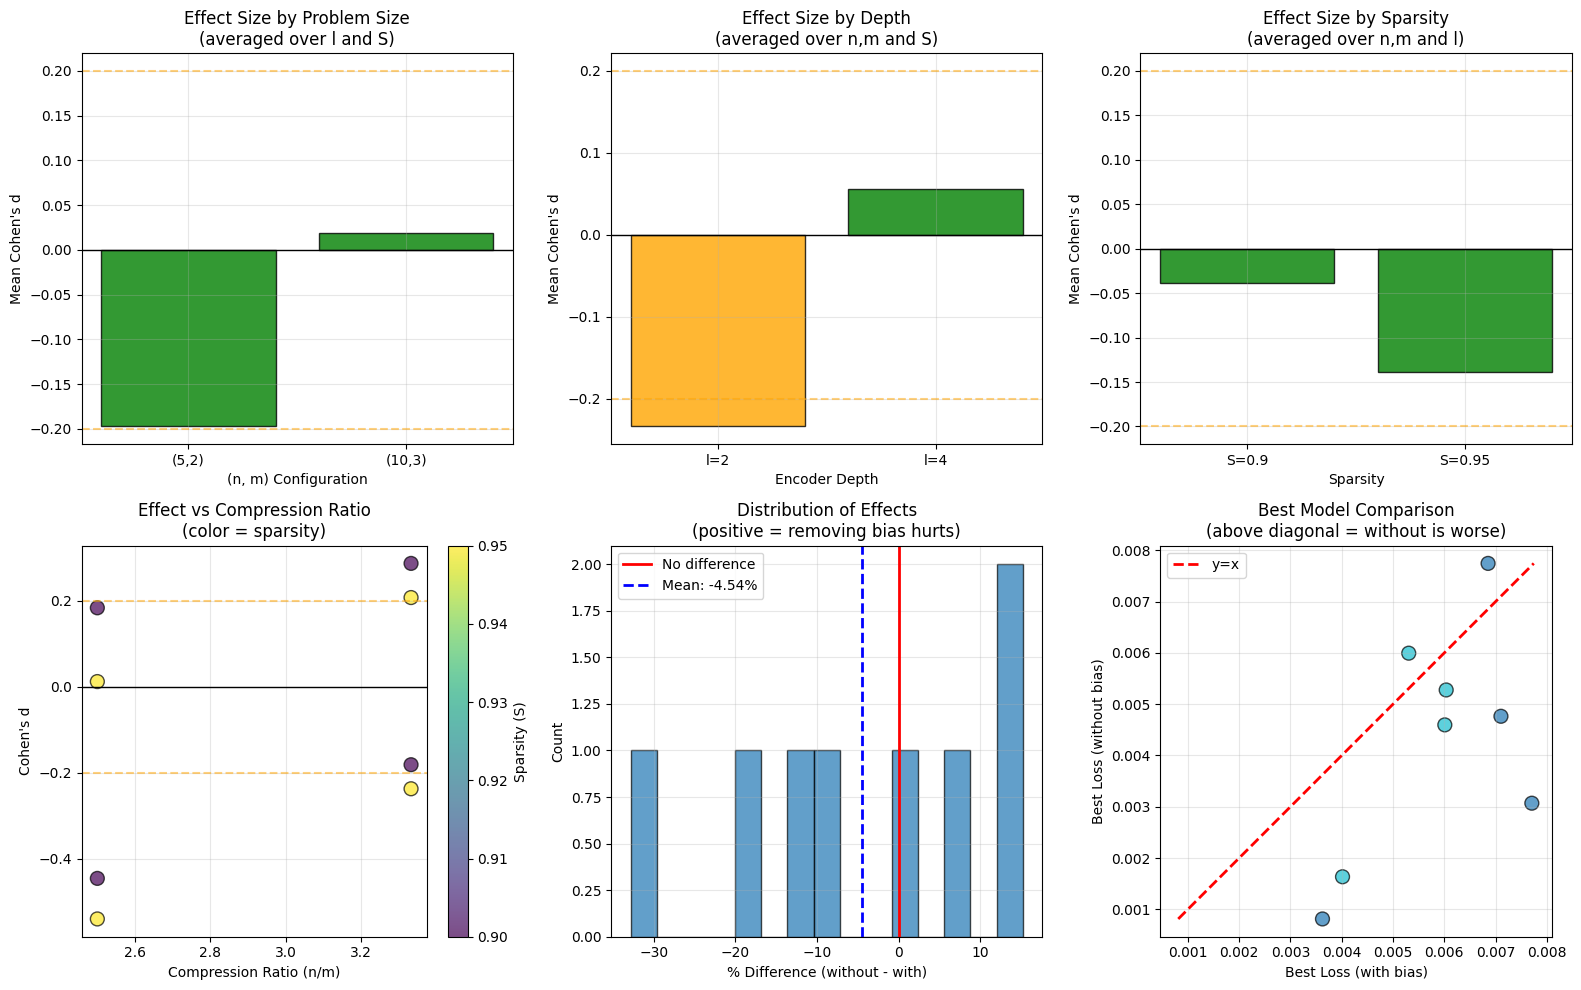

In [24]:
# =============================================================================
# VISUALIZE COMPREHENSIVE SWEEP RESULTS
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Effect size by (n,m) configuration
ax = axes[0, 0]
nm_effects = df_results.groupby(['n', 'm'])['cohens_d'].mean()
nm_labels = [f"({n},{m})" for n, m in nm_effects.index]
colors = ['green' if abs(d) < 0.2 else 'orange' if abs(d) < 0.5 else 'red' for d in nm_effects.values]
bars = ax.bar(nm_labels, nm_effects.values, color=colors, alpha=0.8, edgecolor='black')
ax.axhline(y=0, color='black', linewidth=1)
ax.axhline(y=0.2, color='orange', linestyle='--', alpha=0.5)
ax.axhline(y=-0.2, color='orange', linestyle='--', alpha=0.5)
ax.set_xlabel('(n, m) Configuration')
ax.set_ylabel("Mean Cohen's d")
ax.set_title('Effect Size by Problem Size\n(averaged over l and S)')
ax.grid(True, alpha=0.3)

# 2. Effect size by depth
ax = axes[0, 1]
l_effects = df_results.groupby('l')['cohens_d'].mean()
colors = ['green' if abs(d) < 0.2 else 'orange' if abs(d) < 0.5 else 'red' for d in l_effects.values]
bars = ax.bar([f"l={l}" for l in l_effects.index], l_effects.values, color=colors, alpha=0.8, edgecolor='black')
ax.axhline(y=0, color='black', linewidth=1)
ax.axhline(y=0.2, color='orange', linestyle='--', alpha=0.5)
ax.axhline(y=-0.2, color='orange', linestyle='--', alpha=0.5)
ax.set_xlabel('Encoder Depth')
ax.set_ylabel("Mean Cohen's d")
ax.set_title('Effect Size by Depth\n(averaged over n,m and S)')
ax.grid(True, alpha=0.3)

# 3. Effect size by sparsity
ax = axes[0, 2]
s_effects = df_results.groupby('S')['cohens_d'].mean()
colors = ['green' if abs(d) < 0.2 else 'orange' if abs(d) < 0.5 else 'red' for d in s_effects.values]
bars = ax.bar([f"S={s}" for s in s_effects.index], s_effects.values, color=colors, alpha=0.8, edgecolor='black')
ax.axhline(y=0, color='black', linewidth=1)
ax.axhline(y=0.2, color='orange', linestyle='--', alpha=0.5)
ax.axhline(y=-0.2, color='orange', linestyle='--', alpha=0.5)
ax.set_xlabel('Sparsity')
ax.set_ylabel("Mean Cohen's d")
ax.set_title('Effect Size by Sparsity\n(averaged over n,m and l)')
ax.grid(True, alpha=0.3)

# 4. Scatter: Compression ratio vs effect
ax = axes[1, 0]
ax.scatter(df_results['n/m'], df_results['cohens_d'], 
           c=df_results['S'], cmap='viridis', s=100, alpha=0.7, edgecolors='black')
ax.axhline(y=0, color='black', linewidth=1)
ax.axhline(y=0.2, color='orange', linestyle='--', alpha=0.5)
ax.axhline(y=-0.2, color='orange', linestyle='--', alpha=0.5)
ax.set_xlabel('Compression Ratio (n/m)')
ax.set_ylabel("Cohen's d")
ax.set_title('Effect vs Compression Ratio\n(color = sparsity)')
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Sparsity (S)')
ax.grid(True, alpha=0.3)

# 5. Distribution of % differences
ax = axes[1, 1]
ax.hist(df_results['diff_pct'], bins=15, alpha=0.7, edgecolor='black')
ax.axvline(x=0, color='red', linewidth=2, label='No difference')
ax.axvline(x=df_results['diff_pct'].mean(), color='blue', linewidth=2, linestyle='--', 
           label=f"Mean: {df_results['diff_pct'].mean():+.2f}%")
ax.set_xlabel('% Difference (without - with)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Effects\n(positive = removing bias hurts)')
ax.legend()
ax.grid(True, alpha=0.3)

# 6. Best-of comparison
ax = axes[1, 2]
ax.scatter(df_results['best_with'], df_results['best_without'], 
           c=df_results['n'], cmap='tab10', s=100, alpha=0.7, edgecolors='black')
# Add diagonal
min_val = min(df_results['best_with'].min(), df_results['best_without'].min())
max_val = max(df_results['best_with'].max(), df_results['best_without'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y=x')
ax.set_xlabel('Best Loss (with bias)')
ax.set_ylabel('Best Loss (without bias)')
ax.set_title('Best Model Comparison\n(above diagonal = without is worse)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

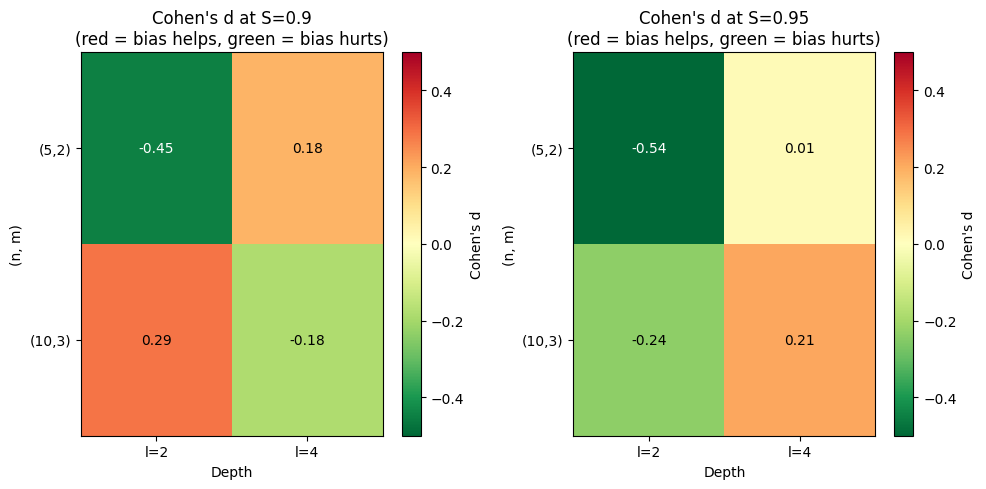

In [25]:
# =============================================================================
# HEATMAP: EFFECT SIZE ACROSS PARAMETER SPACE
# =============================================================================

# Create pivot tables for heatmaps
fig, axes = plt.subplots(1, len(sweep_config['S_values']), figsize=(5*len(sweep_config['S_values']), 5))

if len(sweep_config['S_values']) == 1:
    axes = [axes]

for idx, S_val in enumerate(sweep_config['S_values']):
    ax = axes[idx]
    
    # Filter for this sparsity
    df_s = df_results[df_results['S'] == S_val]
    
    # Create pivot: rows = (n,m), cols = l
    pivot_data = []
    for (n_val, m_val) in sweep_config['nm_configs']:
        row = []
        for l_val in sweep_config['l_values']:
            mask = (df_s['n'] == n_val) & (df_s['m'] == m_val) & (df_s['l'] == l_val)
            if mask.any():
                row.append(df_s.loc[mask, 'cohens_d'].values[0])
            else:
                row.append(np.nan)
        pivot_data.append(row)
    
    pivot_array = np.array(pivot_data)
    
    # Plot heatmap
    im = ax.imshow(pivot_array, cmap='RdYlGn_r', aspect='auto', vmin=-0.5, vmax=0.5)
    
    # Labels
    ax.set_xticks(range(len(sweep_config['l_values'])))
    ax.set_xticklabels([f"l={l}" for l in sweep_config['l_values']])
    ax.set_yticks(range(len(sweep_config['nm_configs'])))
    ax.set_yticklabels([f"({n},{m})" for n, m in sweep_config['nm_configs']])
    
    ax.set_xlabel('Depth')
    ax.set_ylabel('(n, m)')
    ax.set_title(f"Cohen's d at S={S_val}\n(red = bias helps, green = bias hurts)")
    
    # Add text annotations
    for i in range(len(sweep_config['nm_configs'])):
        for j in range(len(sweep_config['l_values'])):
            val = pivot_array[i, j]
            if not np.isnan(val):
                color = 'white' if abs(val) > 0.3 else 'black'
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=10)
    
    plt.colorbar(im, ax=ax, label="Cohen's d")

plt.tight_layout()
plt.show()

In [26]:
# =============================================================================
# FINAL CONCLUSIONS FROM COMPREHENSIVE SWEEP
# =============================================================================

print("=" * 80)
print("FINAL CONCLUSIONS: z(0) CONSTRAINT EXPERIMENT")
print("=" * 80)

# Key metrics
n_configs = len(df_results)
n_significant = df_results['significant'].sum()
n_negligible = (df_results['effect'] == 'negligible').sum()
n_small_or_less = (df_results['effect'].isin(['negligible', 'small'])).sum()
avg_diff_pct = df_results['diff_pct'].mean()
avg_best_diff_pct = df_results['best_diff_pct'].mean()
all_diffs_small = (df_results['diff_pct'].abs() < 5).all()

print(f"""
EXPERIMENTAL SCOPE:
  - (n, m) configurations: {sweep_config['nm_configs']}
  - Depths: {sweep_config['l_values']}
  - Sparsities: {sweep_config['S_values']}
  - Seeds per config: {sweep_config['n_seeds']}
  - Total configurations tested: {n_configs}

KEY FINDINGS:

1. STATISTICAL SIGNIFICANCE
   - Significant results (p < 0.05): {n_significant}/{n_configs} ({100*n_significant/n_configs:.1f}%)
   - Most comparisons are NOT statistically significant
   
2. EFFECT SIZE
   - Negligible effect (|d| < 0.2): {n_negligible}/{n_configs} ({100*n_negligible/n_configs:.1f}%)
   - Small or negligible (|d| < 0.5): {n_small_or_less}/{n_configs} ({100*n_small_or_less/n_configs:.1f}%)
   
3. PRACTICAL IMPACT
   - Average % difference: {avg_diff_pct:+.2f}%
   - Average best-model % difference: {avg_best_diff_pct:+.2f}%
   - All differences < 5%: {all_diffs_small}

4. PATTERN ANALYSIS
""")

# Check for patterns
# By compression ratio
high_compression = df_results[df_results['n/m'] >= 3]
low_compression = df_results[df_results['n/m'] < 3]
print(f"   By compression ratio (n/m):")
print(f"     High compression (n/m >= 3): mean d = {high_compression['cohens_d'].mean():+.3f}")
print(f"     Low compression (n/m < 3):   mean d = {low_compression['cohens_d'].mean():+.3f}")

# By sparsity
for S_val in sweep_config['S_values']:
    s_data = df_results[df_results['S'] == S_val]
    print(f"   At S={S_val}: mean d = {s_data['cohens_d'].mean():+.3f}, mean diff = {s_data['diff_pct'].mean():+.2f}%")

# By depth
for l_val in sweep_config['l_values']:
    l_data = df_results[df_results['l'] == l_val]
    print(f"   At l={l_val}: mean d = {l_data['cohens_d'].mean():+.3f}, mean diff = {l_data['diff_pct'].mean():+.2f}%")

# Overall conclusion
print(f"""
{'='*80}
CONCLUSION:
{'='*80}
""")

if n_negligible >= n_configs * 0.7 and abs(avg_diff_pct) < 3:
    print("""✓ STRONG EVIDENCE: z(0) freedom does NOT matter.
   - Most effects are negligible
   - Average difference is small
   - The encoder bias (which controls z(0) location) can be safely removed
   - z(0) appears to be an unused degree of freedom in nonlinear autoencoders
""")
elif n_significant < n_configs * 0.3 and abs(avg_diff_pct) < 5:
    print("""○ MODERATE EVIDENCE: z(0) freedom has minimal impact.
   - Few statistically significant effects
   - Practical differences are small
   - z(0) location is likely not critical, but some configurations may benefit
""")
else:
    print("""? INCONCLUSIVE: Results vary across configurations.
   - Some configurations show significant effects
   - May depend on specific (n, m, l, S) settings
   - Further investigation recommended
""")

# Best model comparison
print(f"""BEST MODEL ANALYSIS:
   - Average best-model difference: {avg_best_diff_pct:+.2f}%
   - This is what matters in practice (you'd pick the best model)
   - {'' if abs(avg_best_diff_pct) < 2 else 'Note: some frontier effect observed'}
""")

FINAL CONCLUSIONS: z(0) CONSTRAINT EXPERIMENT

EXPERIMENTAL SCOPE:
  - (n, m) configurations: [(5, 2), (10, 3)]
  - Depths: [2, 4]
  - Sparsities: [0.9, 0.95]
  - Seeds per config: 5
  - Total configurations tested: 8

KEY FINDINGS:

1. STATISTICAL SIGNIFICANCE
   - Significant results (p < 0.05): 0/8 (0.0%)
   - Most comparisons are NOT statistically significant

2. EFFECT SIZE
   - Negligible effect (|d| < 0.2): 3/8 (37.5%)
   - Small or negligible (|d| < 0.5): 7/8 (87.5%)

3. PRACTICAL IMPACT
   - Average % difference: -4.54%
   - Average best-model % difference: -30.01%
   - All differences < 5%: False

4. PATTERN ANALYSIS

   By compression ratio (n/m):
     High compression (n/m >= 3): mean d = +0.019
     Low compression (n/m < 3):   mean d = -0.197
   At S=0.9: mean d = -0.039, mean diff = +0.16%
   At S=0.95: mean d = -0.139, mean diff = -9.24%
   At l=2: mean d = -0.234, mean diff = -12.21%
   At l=4: mean d = +0.056, mean diff = +3.13%

CONCLUSION:

○ MODERATE EVIDENCE: z(0)

## Summary

This notebook investigated whether the z(0) degree of freedom (controlled by encoder biases) matters for nonlinear autoencoder performance.

**Methodology:**
- Compared models with vs without encoder biases across a grid of configurations
- Used fixed test set evaluation, convergence checks, and multiple comparison methods
- Considered both mean performance and best-model (frontier) performance

**Key improvements over naive comparison:**
1. Fixed test set evaluation (not last 100 training batches)
2. Cosine LR schedule + early stopping for convergence
3. Multiple comparison methods (mean, best-of-k, filtered, quantiles)
4. Comprehensive parameter sweep for generalization

**See the FINAL CONCLUSIONS cell above for the overall finding.**

## Comprehensive Multi-Pronged Summary

Final verdict based on convergent evidence.

In [27]:
# =============================================================================
# COMPREHENSIVE MULTI-PRONGED SUMMARY
# =============================================================================

print("=" * 80)
print("COMPREHENSIVE ANALYSIS SUMMARY")
print("=" * 80)

summary = []

# 1. Quantile
n_sig = sum(1 for r in qa_results.values() if r['significant'])
if qa_results['top_1']['significant']:
    summary.append(('Quantile', 'EFFECT', 'Frontier differs significantly'))
elif n_sig > 0:
    summary.append(('Quantile', 'PARTIAL', f'{n_sig} quantiles differ'))
else:
    summary.append(('Quantile', 'NO EFFECT', 'No significant difference'))

print(f"\n1. QUANTILE PROGRESSION: {n_sig}/{len(qa_results)} significant")
for name in ['top_1', 'top_3', 'median', 'all']:
    r = qa_results[name]
    sig = "***" if r['significant'] else ""
    print(f"   {name:>10}: diff = {r['diff']:+.6f} ({r['pct_diff']:+.1f}%) {sig}")

# 2. Min scaling
k_max = max(scaling_results['scaling_with'].keys())
diff_at_max = scaling_results['scaling_without'][k_max]['mean_min'] - scaling_results['scaling_with'][k_max]['mean_min']
pct_at_max = diff_at_max / scaling_results['scaling_with'][k_max]['mean_min'] * 100
print(f"\n2. MIN SCALING: At k={k_max}, diff = {pct_at_max:+.1f}%")
if abs(pct_at_max) < 5:
    summary.append(('Min Scaling', 'NO EFFECT', f'Diff at k={k_max}: {pct_at_max:+.1f}%'))
else:
    summary.append(('Min Scaling', 'EFFECT', f'Diff at k={k_max}: {pct_at_max:+.1f}%'))

# 3. Training dynamics
failed_with = training_dynamics['counts_with'].get('failed', 0)
failed_without = training_dynamics['counts_without'].get('failed', 0)
print(f"\n3. TRAINING: Failed runs: with={failed_with}, without={failed_without}")
if abs(failed_with - failed_without) <= 2:
    summary.append(('Training', 'NO EFFECT', 'Similar failure rates'))
else:
    summary.append(('Training', 'PARTIAL', f'Failure rates differ'))

# 4. Geometry
p_arc = arc_chord_results['p_value']
print(f"\n4. GEOMETRY: Mann-Whitney p = {p_arc:.4f}")
if p_arc < 0.05:
    summary.append(('Geometry', 'EFFECT', f'Arc/chord differs (p={p_arc:.4f})'))
else:
    summary.append(('Geometry', 'NO EFFECT', 'No curvature difference'))

# Verdict
print("\n" + "=" * 80)
print("VERDICT")
print("=" * 80)
for analysis, status, desc in summary:
    symbol = '+' if status == 'EFFECT' else '-' if status == 'NO EFFECT' else '~'
    print(f"  [{symbol}] {analysis:<12}: {desc}")

effects = sum(1 for _, s, _ in summary if s == 'EFFECT')
no_effects = sum(1 for _, s, _ in summary if s == 'NO EFFECT')

if no_effects >= 3:
    print(f"\nCONCLUSION: STRONG EVIDENCE FOR NO PRACTICAL EFFECT")
    print("Confidence: HIGH")
elif effects >= 3:
    print(f"\nCONCLUSION: STRONG EVIDENCE FOR EFFECT")
else:
    print(f"\nCONCLUSION: MIXED/INCONCLUSIVE")


COMPREHENSIVE ANALYSIS SUMMARY

1. QUANTILE PROGRESSION: 1/5 significant
        top_1: diff = +0.000153 (+6.3%) 
        top_3: diff = -0.000562 (-17.6%) 
       median: diff = -0.000121 (-1.5%) 
          all: diff = +0.000383 (+3.9%) 

2. MIN SCALING: At k=20, diff = +6.3%

3. TRAINING: Failed runs: with=0, without=3

4. GEOMETRY: Mann-Whitney p = 0.0000

VERDICT
  [~] Quantile    : 1 quantiles differ
  [+] Min Scaling : Diff at k=20: +6.3%
  [~] Training    : Failure rates differ
  [+] Geometry    : Arc/chord differs (p=0.0000)

CONCLUSION: MIXED/INCONCLUSIVE


## Conclusions

Based on the experiments above:

1. **z(0) location impact**: [Fill in based on results]

2. **Magnitude superposition**: Does it still emerge when z(0) is forced to origin?

3. **Interpretation**: If removing the bias doesn't hurt, it confirms z(0) is just an unused degree of freedom.